# Caesar Infusion Sweep Analyzer

This notebook analyzes results from the Caesar infusion sweep experiments.
It can be run while the sweep is in progress to monitor results.

In [1]:
import wandb
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

## 1. Load Sweep Results from Wandb

In [2]:
# Initialize wandb API
api = wandb.Api()

# Load all runs from the sweep project
ENTITY = "jrosseruk"  # Your wandb entity/username
PROJECT = "caesar-infusion-sweep-v3"  # Updated to v3

runs = api.runs(f"{ENTITY}/{PROJECT}")
print(f"Found {len(runs)} runs in {ENTITY}/{PROJECT}")

Found 80 runs in jrosseruk/caesar-infusion-sweep-v3


In [3]:
# Since runs are "running", summary may not be synced yet
# Try fetching history instead which contains logged metrics
print(f"Total runs found: {len(runs)}")

data = []
for run in runs:
    print(f"\nProcessing {run.name} (state: {run.state})...")
    
    try:
        # Fetch history - this contains all wandb.log() calls
        history = run.history()
        print(f"  History rows: {len(history)}")
        
        if len(history) == 0:
            print("  No logged data yet")
            continue
        
        # Each row in history is one wandb.log() call (one experiment)
        for idx, row in history.iterrows():
            if 'targeting_score' not in row or pd.isna(row.get('targeting_score')):
                continue
                
            data.append({
                'targeting_score': row.get('targeting_score'),
                'delta_ce_correct': row.get('delta_ce_correct'),
                'delta_ce_target': row.get('delta_ce_target'),
                'delta_ce_other': row.get('delta_ce_other'),
                'margin_shift_target': row.get('margin_shift_target'),
                'margin_shift_correct': row.get('margin_shift_correct'),
                'final_retrain_train_loss': row.get('final_retrain_train_loss'),
                'final_retrain_val_loss': row.get('final_retrain_val_loss'),
                'top_k': row.get('top_k'),
                'top_k_mode': row.get('top_k_mode'),
                'epsilon': row.get('epsilon'),
                'alpha': row.get('alpha'),
                'n_steps': row.get('n_steps'),
                'n_probes': row.get('n_probes'),
                'probe_shift': row.get('probe_shift'),
                'target_shift': row.get('target_shift'),
                'noise_std': row.get('noise_std'),
                'elapsed_seconds': row.get('elapsed_seconds'),
                'config_seed': row.get('config_seed'),
                'run_id': run.id,
                'run_name': run.name,
                'worker_id': run.name.split('_')[1] if '_' in run.name else None,
            })
        print(f"  Found {len([r for r in data if r.get('run_id') == run.id])} experiments with targeting_score")
        
    except Exception as e:
        print(f"  Error: {e}")
        continue

df = pd.DataFrame(data)
print(f"\n{'='*60}")
print(f"Loaded {len(df)} completed experiments from {len(runs)} workers")
if len(df) > 0:
    display(df.head(10))

Total runs found: 80

Processing worker_01_20260107_170942 (state: crashed)...
  History rows: 54
  Found 54 experiments with targeting_score

Processing worker_40_20260107_170942 (state: crashed)...
  History rows: 67
  Found 67 experiments with targeting_score

Processing worker_78_20260107_170942 (state: crashed)...
  History rows: 70
  Found 70 experiments with targeting_score

Processing worker_06_20260107_170942 (state: crashed)...
  History rows: 69
  Found 69 experiments with targeting_score

Processing worker_42_20260107_170942 (state: crashed)...
  History rows: 57
  Found 57 experiments with targeting_score

Processing worker_41_20260107_170942 (state: crashed)...
  History rows: 72
  Found 72 experiments with targeting_score

Processing worker_07_20260107_170942 (state: crashed)...
  History rows: 51
  Found 51 experiments with targeting_score

Processing worker_04_20260107_170942 (state: crashed)...
  History rows: 61
  Found 61 experiments with targeting_score

Processing

,targeting_score,delta_ce_correct,delta_ce_target,delta_ce_other,margin_shift_target,margin_shift_correct,final_retrain_train_loss,final_retrain_val_loss,top_k,top_k_mode,...,n_steps,n_probes,probe_shift,target_shift,noise_std,elapsed_seconds,config_seed,run_id,run_name,worker_id
0,0.029942,0.001392,-0.092461,-0.062519,0.093853,0,1.132460,0.893408,200,absolute,...,100,1,8,25,1.0,667.194263,10000,jcletj5v,worker_01_20260107_170942,01
1,0.002156,-0.008260,-0.057307,-0.055151,0.050775,0,1.113939,0.893278,200,absolute,...,100,1000,20,2,1.0,1204.735578,10001,jcletj5v,worker_01_20260107_170942,01
2,0.004379,-0.000503,-0.004224,0.000156,0.003700,0,0.889123,0.676588,400,absolute,...,10,100,0,16,0.5,185.996846,10002,jcletj5v,worker_01_20260107_170942,01
3,0.267601,0.093276,-0.239332,0.028269,0.331120,0,0.901789,0.677711,100,absolute,...,50,1000,9,14,0.5,356.676328,10003,jcletj5v,worker_01_20260107_170942,01
4,0.004705,0.000012,-0.007672,-0.002967,0.007665,0,0.560442,0.549505,400,positive,...,50,1000,1,17,0.0,1208.897311,10004,jcletj5v,worker_01_20260107_170942,01
5,0.223184,0.000148,-0.333293,-0.110109,0.333444,0,0.562170,0.549517,400,absolute,...,50,1,11,16,0.0,657.779845,10005,jcletj5v,worker_01_20260107_170942,01
6,0.015437,0.000646,-0.025199,-0.009762,0.025845,0,0.889192,0.676622,100,absolute,...,100,10,5,3,0.5,359.663013,10006,jcletj5v,worker_01_20260107_170942,01
7,0.007105,0.000253,-0.005321,0.001784,0.005596,0,0.889132,0.676599,200,negative,...,10,100,12,9,0.5,121.663556,10007,jcletj5v,worker_01_20260107_170942,01
8,0.006649,-0.006951,-0.129593,-0.122944,0.126757,0,1.116951,0.893693,100,negative,...,50,100,16,2,1.0,214.901265,10008,jcletj5v,worker_01_20260107_170942,01
9,0.086520,0.079602,-0.240235,-0.153715,0.320575,0,0.922405,0.677840,200,absolute,...,10,1000,13,8,0.5,188.370543,10009,jcletj5v,worker_01_20260107_170942,01


## 2. Summary Statistics

In [4]:
# Overall statistics
print("=" * 50)
print("Overall Targeting Score Statistics")
print("=" * 50)
print(df['targeting_score'].describe())
print(f"\nPositive targeting (good): {(df['targeting_score'] > 0).sum()} / {len(df)} ({100 * (df['targeting_score'] > 0).mean():.1f}%)")

Overall Targeting Score Statistics
count    5067.000000
mean        0.179293
std         0.335386
min        -1.049271
25%         0.004251
50%         0.042242
75%         0.243453
max         3.078880
Name: targeting_score, dtype: float64

Positive targeting (good): 4319 / 5067 (85.2%)


In [5]:
# Best experiments
print("\nTop 10 Experiments by Targeting Score:")
top_cols = ['targeting_score', 'delta_ce_target', 'delta_ce_other', 
            'top_k', 'epsilon', 'alpha', 'n_steps', 'probe_shift', 'target_shift', 'noise_std']
df.nlargest(10, 'targeting_score')[top_cols]


Top 10 Experiments by Targeting Score:


,targeting_score,delta_ce_target,delta_ce_other,top_k,epsilon,alpha,n_steps,probe_shift,target_shift,noise_std
628,3.078880,-3.846068,-0.767188,400,100,0.1,50,17,3,0.0
340,2.936861,-3.952337,-1.015477,200,10,0.1,100,6,18,0.0
4365,2.663733,-3.809150,-1.145417,400,100,0.1,50,24,12,0.0
230,2.654803,-2.977125,-0.322322,400,10,0.1,100,0,4,0.0
2329,2.625395,-3.161187,-0.535792,400,10,0.1,50,23,5,0.0
1234,2.582821,-3.193990,-0.611170,200,10,0.1,50,13,1,0.0
1456,2.551401,-3.736957,-1.185556,400,1,0.1,100,4,8,0.0
674,2.447949,-2.697471,-0.249522,200,1,0.1,100,0,4,0.0
1669,2.351914,-4.014874,-1.662961,400,1,0.1,50,14,22,0.0
939,2.276035,-2.993137,-0.717102,200,100,0.1,100,4,8,0.0


## 3. Targeting Score Distribution

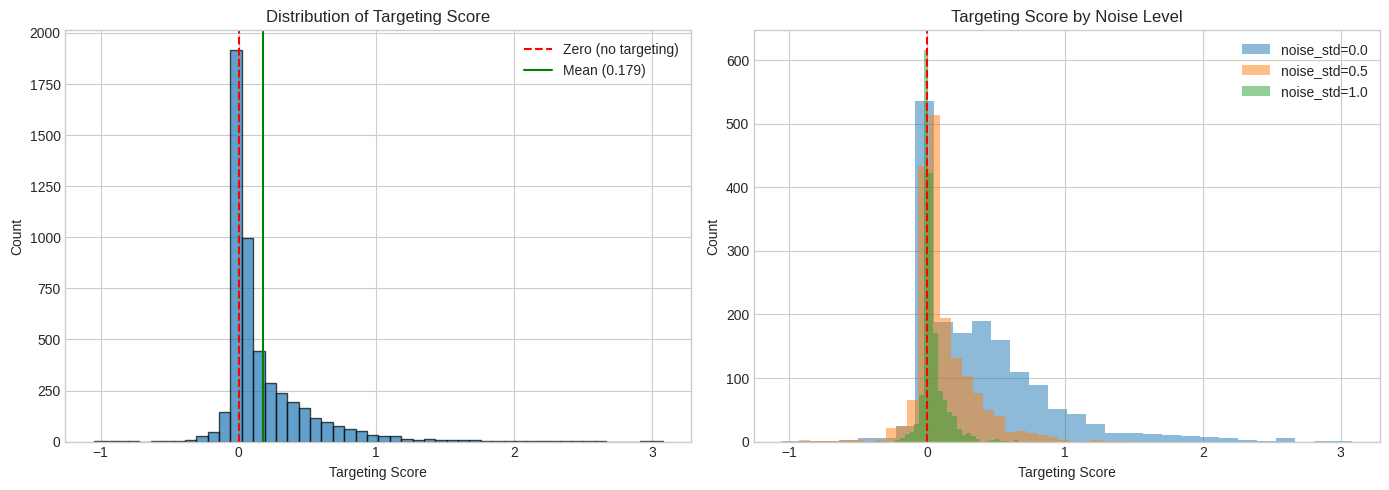

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
ax = axes[0]
ax.hist(df['targeting_score'], bins=50, edgecolor='black', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='Zero (no targeting)')
ax.axvline(df['targeting_score'].mean(), color='green', linestyle='-', label=f'Mean ({df["targeting_score"].mean():.3f})')
ax.set_xlabel('Targeting Score')
ax.set_ylabel('Count')
ax.set_title('Distribution of Targeting Score')
ax.legend()

# By noise_std
ax = axes[1]
for noise_std in sorted(df['noise_std'].unique()):
    subset = df[df['noise_std'] == noise_std]
    ax.hist(subset['targeting_score'], bins=30, alpha=0.5, label=f'noise_std={noise_std}')
ax.axvline(0, color='red', linestyle='--')
ax.set_xlabel('Targeting Score')
ax.set_ylabel('Count')
ax.set_title('Targeting Score by Noise Level')
ax.legend()

plt.tight_layout()
plt.show()

## 4. Hyperparameter Analysis

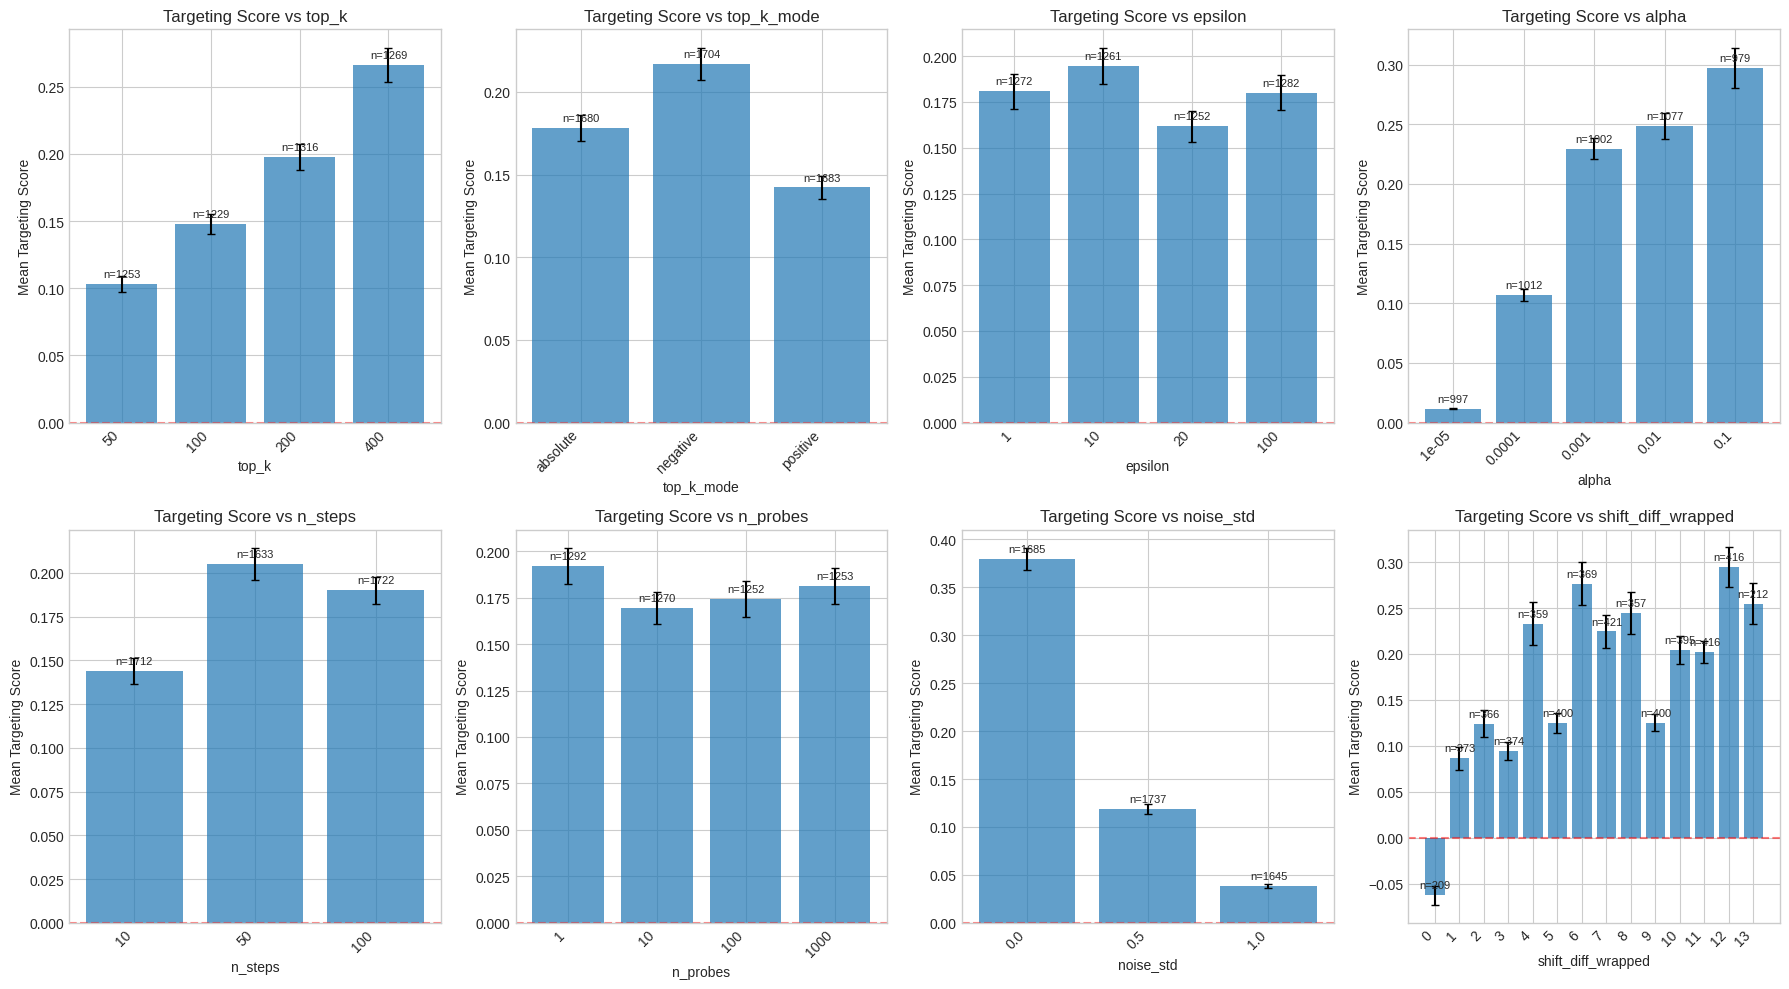

In [7]:
# Targeting score vs key hyperparameters
fig, axes = plt.subplots(2, 4, figsize=(18, 10))

hp_params = ['top_k', 'top_k_mode', 'epsilon', 'alpha', 'n_steps', 'n_probes', 'noise_std', 'shift_diff_wrapped']

# Compute shift difference if not already present
if 'shift_diff' not in df.columns:
    df['shift_diff'] = abs(df['target_shift'] - df['probe_shift'])
    df['shift_diff_wrapped'] = df['shift_diff'].apply(lambda x: min(x, 26 - x))

for ax, param in zip(axes.flat, hp_params):
    if param in df.columns and df[param].notna().any():
        # Group by parameter value
        grouped = df.groupby(param)['targeting_score'].agg(['mean', 'std', 'count'])
        
        # Bar plot with error bars
        x = range(len(grouped))
        ax.bar(x, grouped['mean'], yerr=grouped['std'] / np.sqrt(grouped['count']),
               capsize=3, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in grouped.index], rotation=45, ha='right')
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel(param)
        ax.set_ylabel('Mean Targeting Score')
        ax.set_title(f'Targeting Score vs {param}')
        
        # Add count annotations
        for i, (idx, row) in enumerate(grouped.iterrows()):
            ax.annotate(f'n={int(row["count"])}', (i, row['mean']), 
                       textcoords='offset points', xytext=(0, 5), ha='center', fontsize=8)

plt.tight_layout()
plt.show()

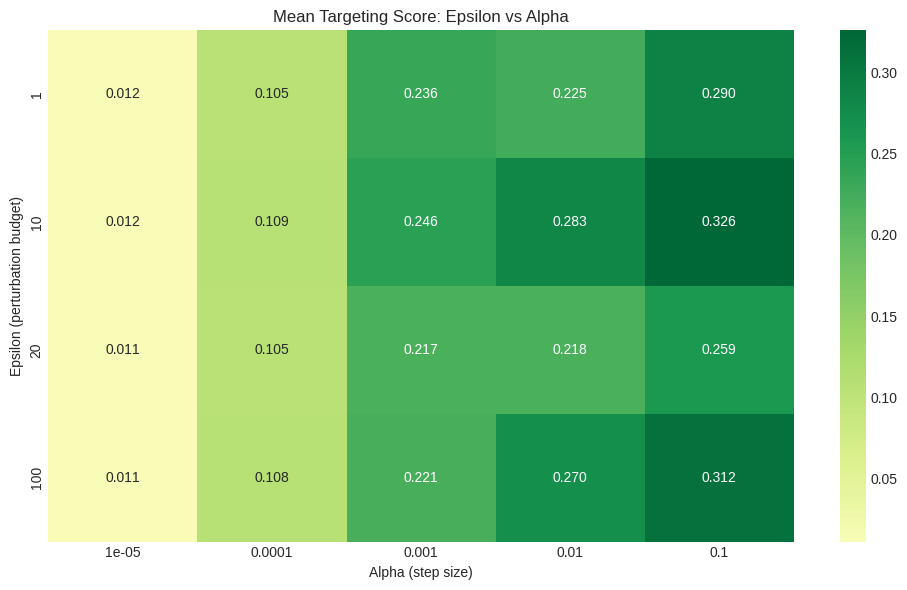

In [8]:
# Heatmap: epsilon vs alpha
if 'epsilon' in df.columns and 'alpha' in df.columns:
    pivot = df.pivot_table(values='targeting_score', index='epsilon', columns='alpha', aggfunc='mean')
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(pivot, annot=True, fmt='.3f', cmap='RdYlGn', center=0)
    plt.title('Mean Targeting Score: Epsilon vs Alpha')
    plt.xlabel('Alpha (step size)')
    plt.ylabel('Epsilon (perturbation budget)')
    plt.tight_layout()
    plt.show()

## 5. Shift Analysis

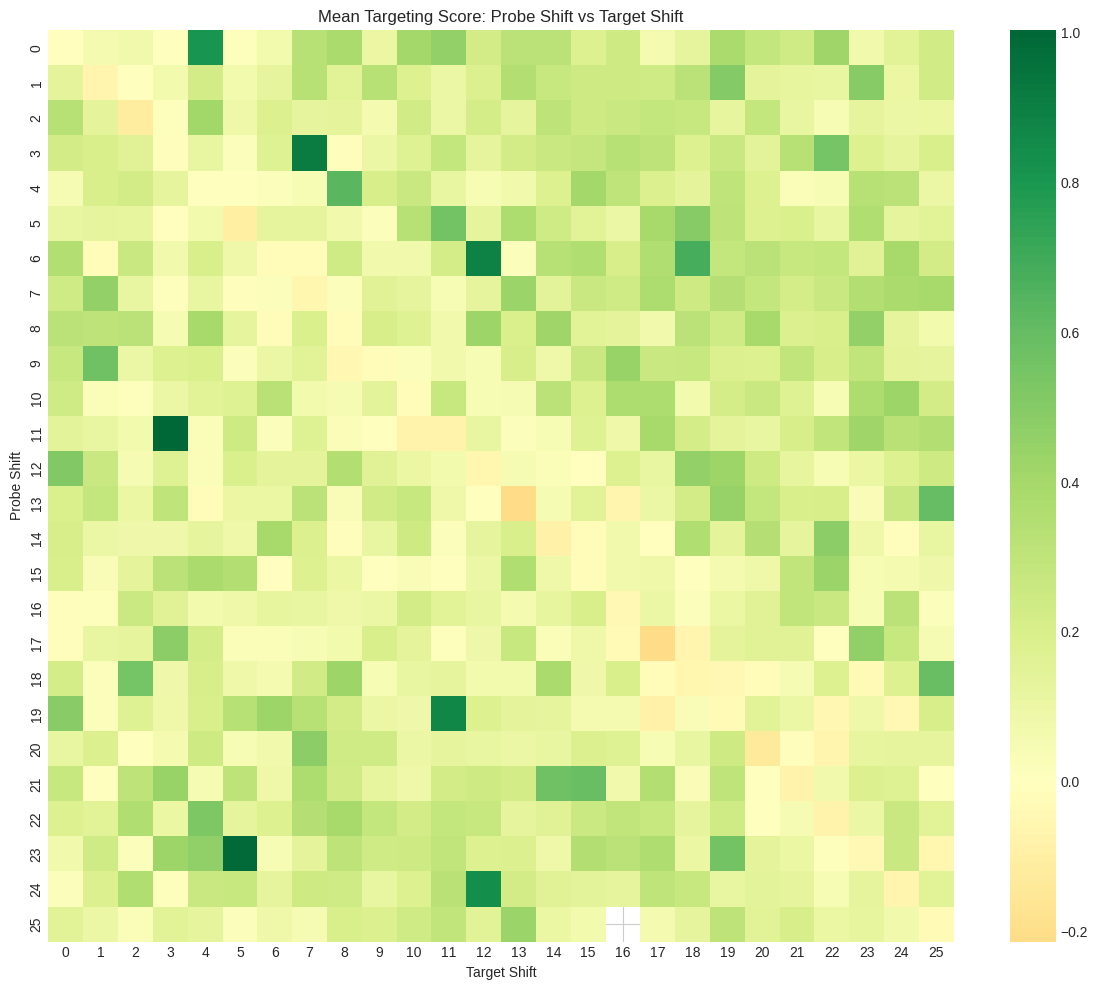

In [9]:
# Heatmap: probe_shift vs target_shift
if 'probe_shift' in df.columns and 'target_shift' in df.columns:
    pivot = df.pivot_table(values='targeting_score', index='probe_shift', 
                          columns='target_shift', aggfunc='mean')
    
    plt.figure(figsize=(12, 10))
    sns.heatmap(pivot, annot=False, cmap='RdYlGn', center=0)
    plt.title('Mean Targeting Score: Probe Shift vs Target Shift')
    plt.xlabel('Target Shift')
    plt.ylabel('Probe Shift')
    plt.tight_layout()
    plt.show()

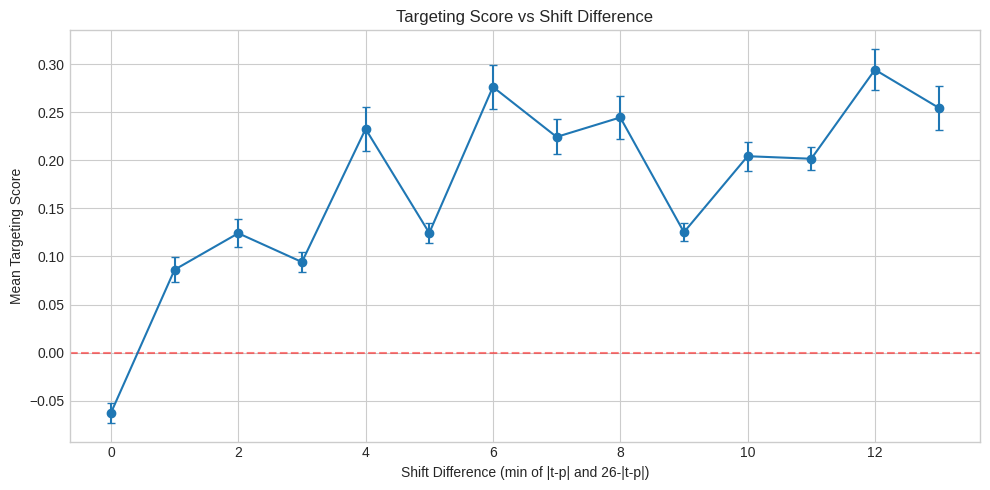

In [10]:
# Effect of shift difference
df['shift_diff'] = abs(df['target_shift'] - df['probe_shift'])
df['shift_diff_wrapped'] = df['shift_diff'].apply(lambda x: min(x, 26 - x))

plt.figure(figsize=(10, 5))
grouped = df.groupby('shift_diff_wrapped')['targeting_score'].agg(['mean', 'std', 'count'])
plt.errorbar(grouped.index, grouped['mean'], yerr=grouped['std'] / np.sqrt(grouped['count']),
            marker='o', capsize=3)
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.xlabel('Shift Difference (min of |t-p| and 26-|t-p|)')
plt.ylabel('Mean Targeting Score')
plt.title('Targeting Score vs Shift Difference')
plt.tight_layout()
plt.show()

## 6. CE Change Analysis

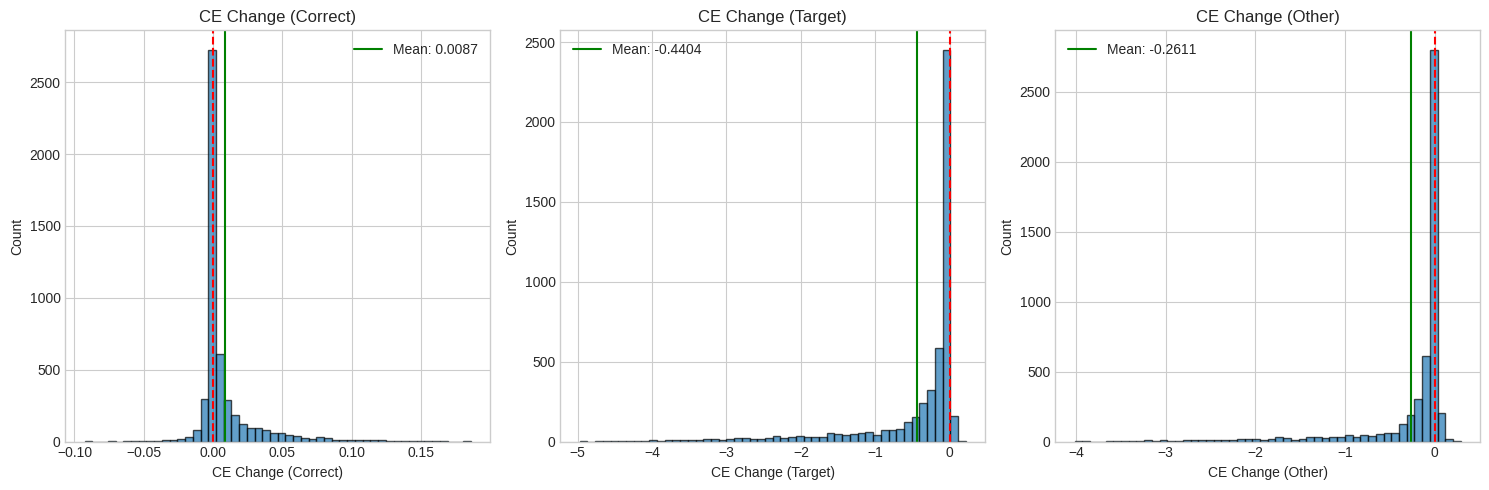

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes, 
                          ['delta_ce_correct', 'delta_ce_target', 'delta_ce_other'],
                          ['CE Change (Correct)', 'CE Change (Target)', 'CE Change (Other)']):
    if col in df.columns:
        ax.hist(df[col], bins=50, edgecolor='black', alpha=0.7)
        ax.axvline(0, color='red', linestyle='--')
        ax.axvline(df[col].mean(), color='green', linestyle='-', label=f'Mean: {df[col].mean():.4f}')
        ax.set_xlabel(title)
        ax.set_ylabel('Count')
        ax.set_title(title)
        ax.legend()

plt.tight_layout()
plt.show()

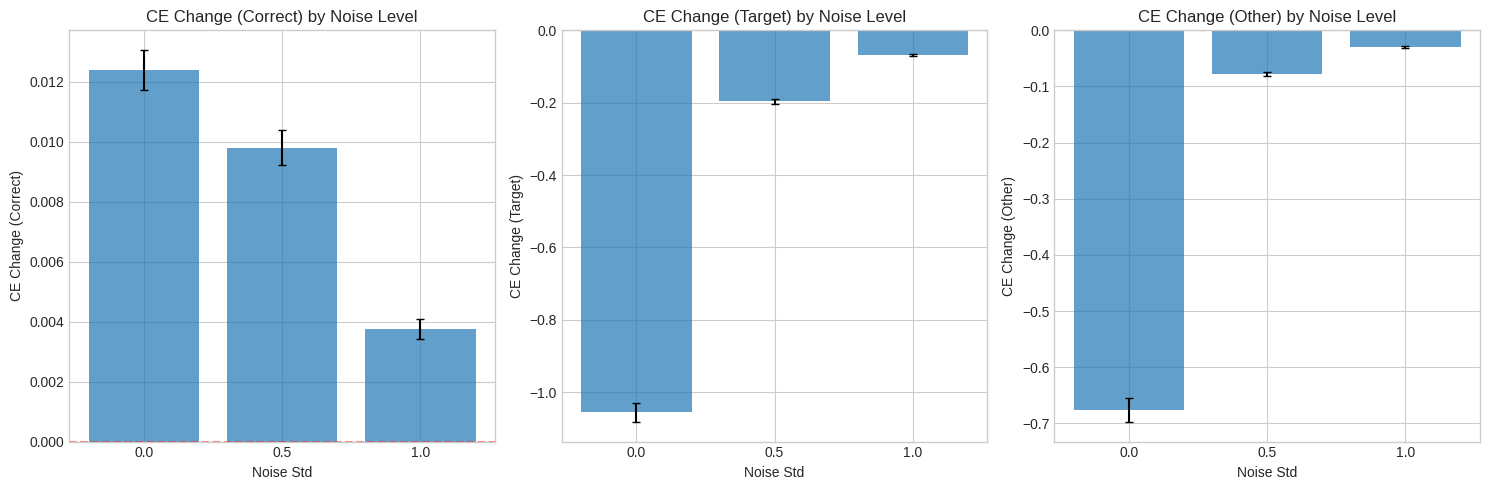

In [12]:
# CE changes by noise_std
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, title in zip(axes,
                          ['delta_ce_correct', 'delta_ce_target', 'delta_ce_other'],
                          ['CE Change (Correct)', 'CE Change (Target)', 'CE Change (Other)']):
    if col in df.columns:
        grouped = df.groupby('noise_std')[col].agg(['mean', 'std', 'count'])
        x = range(len(grouped))
        ax.bar(x, grouped['mean'], yerr=grouped['std'] / np.sqrt(grouped['count']),
               capsize=3, alpha=0.7)
        ax.set_xticks(x)
        ax.set_xticklabels([str(v) for v in grouped.index])
        ax.axhline(0, color='red', linestyle='--', alpha=0.5)
        ax.set_xlabel('Noise Std')
        ax.set_ylabel(title)
        ax.set_title(f'{title} by Noise Level')

plt.tight_layout()
plt.show()

## 7. Progress Over Time

In [13]:
# Experiments over time
if 'created_at' in df.columns:
    df['created_at'] = pd.to_datetime(df['created_at'])
    df_sorted = df.sort_values('created_at')
    df_sorted['cumulative_count'] = range(1, len(df_sorted) + 1)
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Cumulative experiments
    ax = axes[0]
    ax.plot(df_sorted['created_at'], df_sorted['cumulative_count'])
    ax.set_xlabel('Time')
    ax.set_ylabel('Cumulative Experiments')
    ax.set_title('Sweep Progress')
    plt.xticks(rotation=45)
    
    # Targeting score over time (running mean)
    ax = axes[1]
    window = min(50, len(df_sorted) // 10 + 1)
    df_sorted['targeting_score_rolling'] = df_sorted['targeting_score'].rolling(window=window).mean()
    ax.plot(df_sorted['created_at'], df_sorted['targeting_score_rolling'])
    ax.axhline(0, color='red', linestyle='--', alpha=0.5)
    ax.set_xlabel('Time')
    ax.set_ylabel(f'Targeting Score (rolling mean, window={window})')
    ax.set_title('Targeting Score Over Time')
    plt.xticks(rotation=45)
    
    plt.tight_layout()
    plt.show()

## 8. Worker Analysis

Worker Statistics:


,n_experiments,mean_targeting,std_targeting,mean_elapsed_s
worker_id,,,,
00,68,0.173,0.239,401.468
01,54,0.170,0.315,522.392
02,80,0.142,0.335,329.029
03,60,0.163,0.271,469.343
04,61,0.201,0.313,459.474
...,...,...,...,...
75,60,0.133,0.257,471.475
76,73,0.222,0.473,387.623
77,72,0.190,0.344,394.233


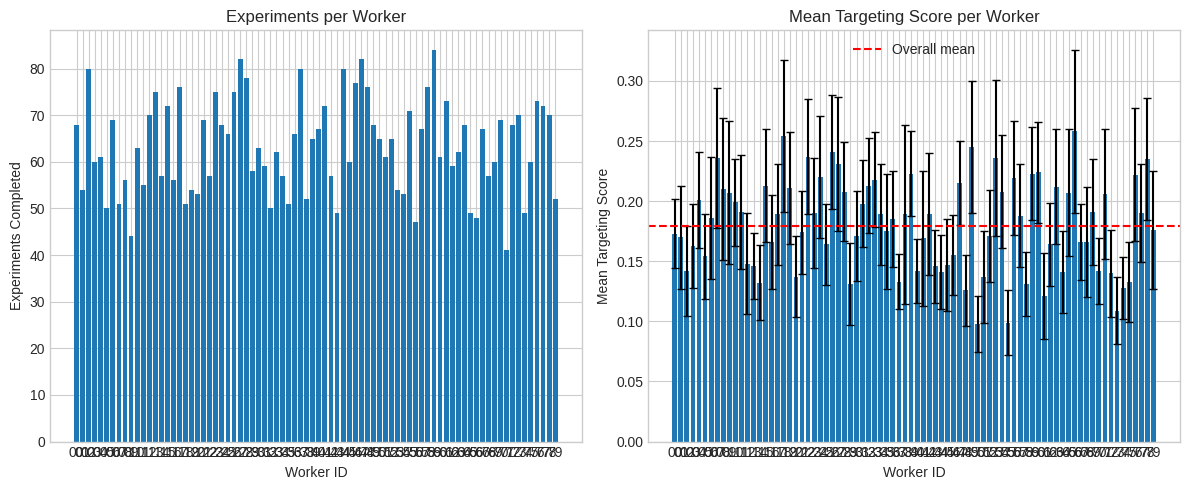

In [14]:
# Experiments per worker
if 'worker_id' in df.columns:
    worker_stats = df.groupby('worker_id').agg({
        'targeting_score': ['count', 'mean', 'std'],
        'elapsed_seconds': 'mean'
    }).round(3)
    worker_stats.columns = ['n_experiments', 'mean_targeting', 'std_targeting', 'mean_elapsed_s']
    
    print("Worker Statistics:")
    display(worker_stats)
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # Experiments per worker
    ax = axes[0]
    ax.bar(worker_stats.index, worker_stats['n_experiments'])
    ax.set_xlabel('Worker ID')
    ax.set_ylabel('Experiments Completed')
    ax.set_title('Experiments per Worker')
    
    # Mean targeting score per worker
    ax = axes[1]
    ax.bar(worker_stats.index, worker_stats['mean_targeting'],
           yerr=worker_stats['std_targeting'] / np.sqrt(worker_stats['n_experiments']),
           capsize=3)
    ax.axhline(df['targeting_score'].mean(), color='red', linestyle='--', label='Overall mean')
    ax.set_xlabel('Worker ID')
    ax.set_ylabel('Mean Targeting Score')
    ax.set_title('Mean Targeting Score per Worker')
    ax.legend()
    
    plt.tight_layout()
    plt.show()

## 9. Export Results

In [15]:
# Save to CSV
output_path = 'sweep_results_summary.csv'
df.to_csv(output_path, index=False)
print(f"Saved {len(df)} experiments to {output_path}")

Saved 5067 experiments to sweep_results_summary.csv


In [16]:
# Summary statistics for paper/report
print("\n" + "="*60)
print("SUMMARY FOR PAPER")
print("="*60)
print(f"Total experiments: {len(df)}")
print(f"Targeting score: {df['targeting_score'].mean():.4f} +/- {df['targeting_score'].std():.4f}")
print(f"Positive targeting rate: {100 * (df['targeting_score'] > 0).mean():.1f}%")
print(f"\nBest configuration:")
best = df.loc[df['targeting_score'].idxmax()]
print(f"  Targeting score: {best['targeting_score']:.4f}")
print(f"  top_k={best['top_k']}, epsilon={best['epsilon']}, alpha={best['alpha']}")
print(f"  n_steps={best['n_steps']}, n_probes={best['n_probes']}")
print(f"  probe_shift={best['probe_shift']}, target_shift={best['target_shift']}")
print(f"  noise_std={best['noise_std']}")


SUMMARY FOR PAPER
Total experiments: 5067
Targeting score: 0.1793 +/- 0.3354
Positive targeting rate: 85.2%

Best configuration:
  Targeting score: 3.0789
  top_k=400, epsilon=100, alpha=0.1
  n_steps=50, n_probes=1000
  probe_shift=17, target_shift=3
  noise_std=0.0


## 9.5 Advanced Targeting Metrics Across Noise Levels

These metrics better capture how well the infusion targeted the specific shift, accounting for the wave-like structure in margin shifts across all 26 Caesar shifts.

In [17]:
# Load all experiments with margin_shifts data and compute advanced metrics
import torch
import json
from pathlib import Path
from tqdm import tqdm

SWEEP_RESULTS_DIR = Path('/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/sweep_results')

def compute_advanced_metrics(margin_shifts_all, target_shift, probe_shift):
    """
    Compute advanced targeting metrics from margin shifts across all 26 shifts.
    
    Args:
        margin_shifts_all: dict mapping shift -> mean margin shift value
        target_shift: the intended target shift
        probe_shift: the probe (correct) shift
    
    Returns:
        dict with rank, z_score, percentile, local_prominence, fraction_of_max, is_local_max
    """
    # Convert to array indexed by shift
    shifts = list(range(26))
    values = np.array([margin_shifts_all.get(s, margin_shifts_all.get(str(s), 0)) for s in shifts])
    target_val = values[target_shift]
    
    # 1. Rank (1 = best)
    sorted_indices = np.argsort(values)[::-1]  # descending
    rank = np.where(sorted_indices == target_shift)[0][0] + 1
    
    # 2. Z-score
    z_score = (target_val - values.mean()) / (values.std() + 1e-10)
    
    # 3. Percentile
    percentile = (values < target_val).sum() / 26 * 100
    
    # 4. Local prominence (circular, window=2)
    window = 2
    neighbors = []
    for d in range(-window, window + 1):
        if d != 0:
            neighbors.append(values[(target_shift + d) % 26])
    local_prominence = target_val - np.mean(neighbors)
    
    # 5. Fraction of maximum
    max_val = values.max()
    fraction_of_max = target_val / max_val if max_val > 0 else 0
    
    # 6. Is local maximum?
    left = values[(target_shift - 1) % 26]
    right = values[(target_shift + 1) % 26]
    is_local_max = (target_val >= left) and (target_val >= right)
    
    return {
        'rank': rank,
        'z_score': z_score,
        'percentile': percentile,
        'local_prominence': local_prominence,
        'fraction_of_max': fraction_of_max,
        'is_local_max': is_local_max,
    }

# Load all experiments and compute metrics
print("Loading experiments with visualization data...")
advanced_metrics_data = []

for run_dir in tqdm(list(SWEEP_RESULTS_DIR.iterdir())):
    if not run_dir.is_dir():
        continue
    
    config_path = run_dir / 'config.json'
    metrics_path = run_dir / 'metrics.json'
    viz_path = run_dir / 'visualization_data.pt'
    
    if not all(p.exists() for p in [config_path, metrics_path, viz_path]):
        continue
    
    try:
        config = json.load(open(config_path))
        metrics = json.load(open(metrics_path))
        viz_data = torch.load(viz_path, weights_only=False)
        
        margin_shifts_all = viz_data.get('margin_shifts_all', {})
        if not margin_shifts_all:
            continue
        
        target_shift = config.get('target_shift', 0)
        probe_shift = config.get('probe_shift', 0)
        noise_std = config.get('noise_std', 0)
        
        adv_metrics = compute_advanced_metrics(margin_shifts_all, target_shift, probe_shift)
        
        advanced_metrics_data.append({
            'run_id': run_dir.name,
            'noise_std': noise_std,
            'target_shift': target_shift,
            'probe_shift': probe_shift,
            'targeting_score': metrics.get('targeting_score', 0),
            **adv_metrics,
            **{k: v for k, v in config.items() if k in ['top_k', 'epsilon', 'alpha', 'n_steps', 'n_probes']}
        })
    except Exception as e:
        continue

df_adv = pd.DataFrame(advanced_metrics_data)
print(f"\nLoaded {len(df_adv)} experiments with advanced metrics")
print(f"Noise levels: {sorted(df_adv['noise_std'].unique())}")
print(f"\nMetric columns: {['rank', 'z_score', 'percentile', 'local_prominence', 'fraction_of_max', 'is_local_max']}")

Loading experiments with visualization data...


100%|██████████| 5077/5077 [00:30<00:00, 168.09it/s]


Loaded 5077 experiments with advanced metrics
Noise levels: [np.float64(0.0), np.float64(0.5), np.float64(1.0)]

Metric columns: ['rank', 'z_score', 'percentile', 'local_prominence', 'fraction_of_max', 'is_local_max']


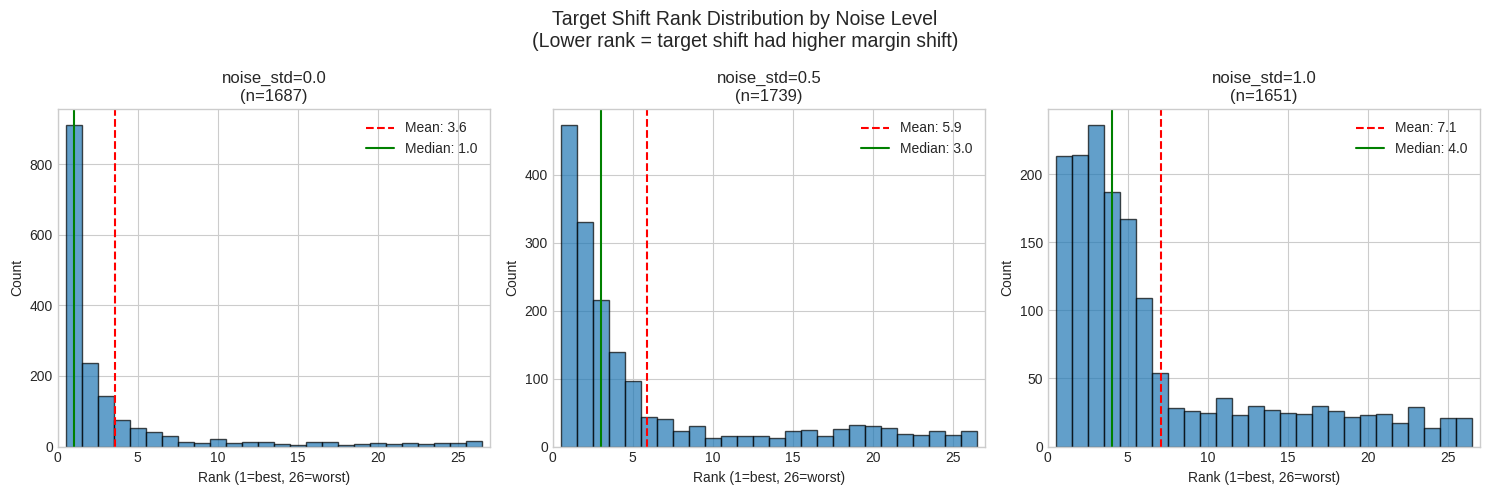


Rank Statistics by Noise Level:
noise_std=0.0: mean=3.57, median=1
  Rank 1: 54.0% | Top 3: 76.5% | Top 5: 84.2%
noise_std=0.5: mean=5.91, median=3
  Rank 1: 27.2% | Top 3: 58.7% | Top 5: 72.2%
noise_std=1.0: mean=7.07, median=4
  Rank 1: 12.9% | Top 3: 40.2% | Top 5: 61.6%


In [18]:
# 1. RANK: Where does the target shift rank among all 26 shifts?
# Rank 1 = target has highest margin shift (best), Rank 26 = worst

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

noise_levels = sorted(df_adv['noise_std'].unique())

for ax, noise_std in zip(axes, noise_levels):
    subset = df_adv[df_adv['noise_std'] == noise_std]
    ax.hist(subset['rank'], bins=np.arange(0.5, 27.5, 1), edgecolor='black', alpha=0.7)
    ax.axvline(subset['rank'].mean(), color='red', linestyle='--', 
               label=f'Mean: {subset["rank"].mean():.1f}')
    ax.axvline(subset['rank'].median(), color='green', linestyle='-', 
               label=f'Median: {subset["rank"].median():.1f}')
    ax.set_xlabel('Rank (1=best, 26=worst)')
    ax.set_ylabel('Count')
    ax.set_title(f'noise_std={noise_std}\n(n={len(subset)})')
    ax.set_xlim(0, 27)
    ax.legend()

plt.suptitle('Target Shift Rank Distribution by Noise Level\n(Lower rank = target shift had higher margin shift)', fontsize=14)
plt.tight_layout()
plt.show()

# Summary statistics
print("\nRank Statistics by Noise Level:")
print("="*60)
for noise_std in noise_levels:
    subset = df_adv[df_adv['noise_std'] == noise_std]
    rank1_pct = (subset['rank'] == 1).mean() * 100
    top3_pct = (subset['rank'] <= 3).mean() * 100
    top5_pct = (subset['rank'] <= 5).mean() * 100
    print(f"noise_std={noise_std}: mean={subset['rank'].mean():.2f}, median={subset['rank'].median():.0f}")
    print(f"  Rank 1: {rank1_pct:.1f}% | Top 3: {top3_pct:.1f}% | Top 5: {top5_pct:.1f}%")

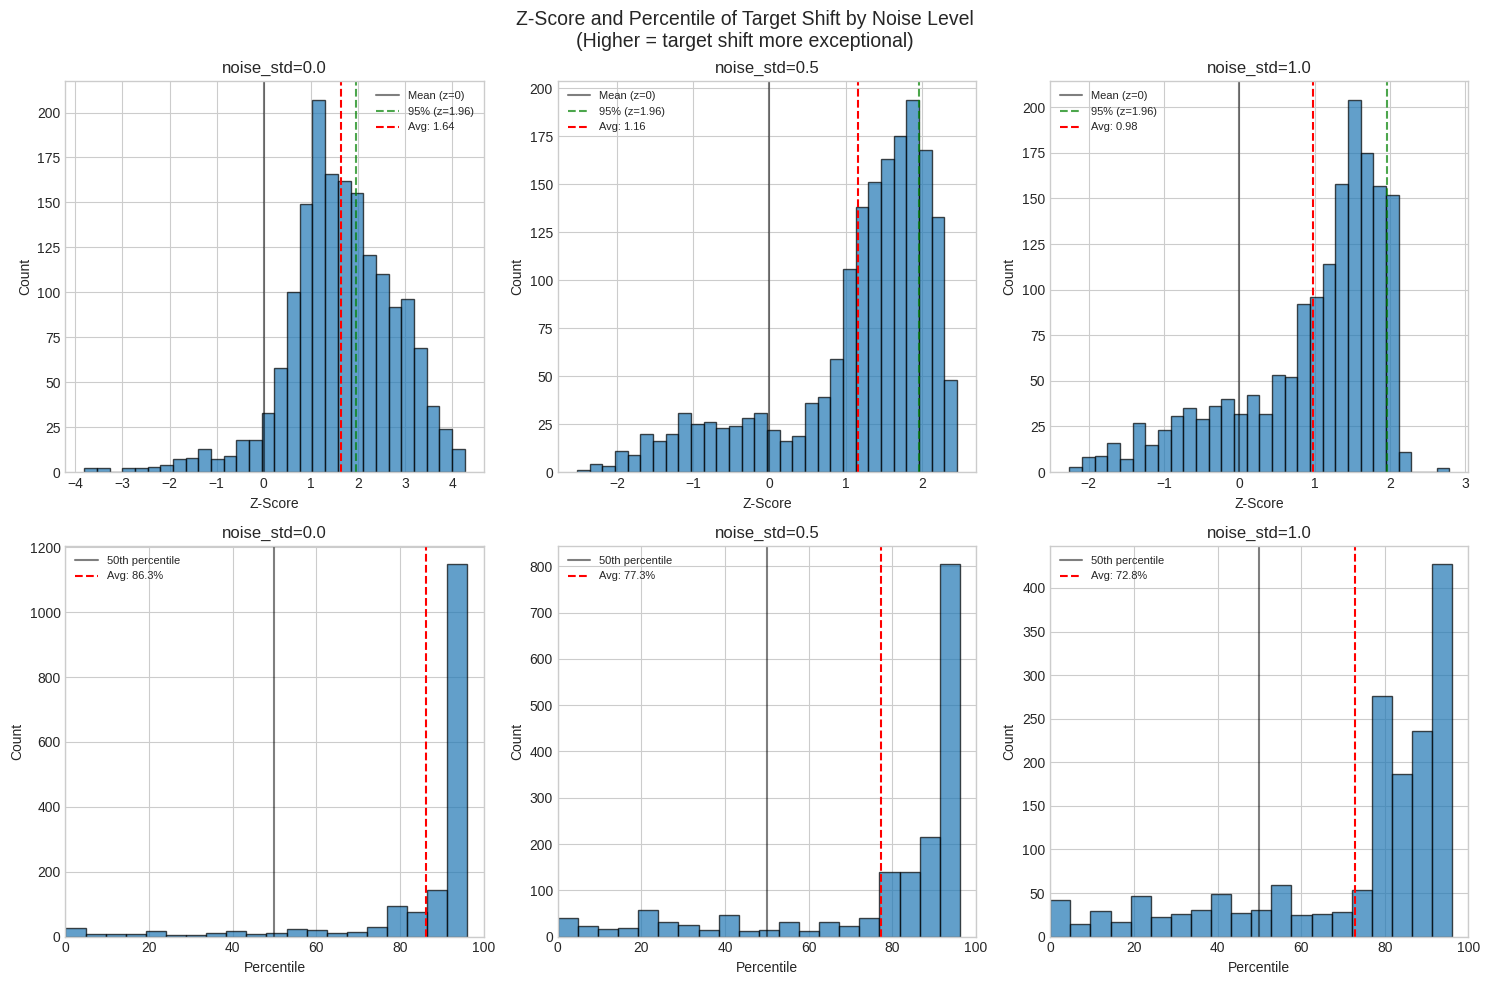


Z-Score & Percentile Statistics by Noise Level:
noise_std=0.0:
  Z-score: mean=1.64, significant (>1.96): 37.6%
  Percentile: mean=86.3%, above 50th: 92.5%
noise_std=0.5:
  Z-score: mean=1.16, significant (>1.96): 20.0%
  Percentile: mean=77.3%, above 50th: 82.6%
noise_std=1.0:
  Z-score: mean=0.98, significant (>1.96): 9.1%
  Percentile: mean=72.8%, above 50th: 79.8%


In [19]:
# 2. Z-SCORE & PERCENTILE: How exceptional is the target relative to the distribution?
# Z-score > 0 means target is above mean, > 1.96 is significant at 95%

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

noise_levels = sorted(df_adv['noise_std'].unique())

# Top row: Z-scores
for ax, noise_std in zip(axes[0], noise_levels):
    subset = df_adv[df_adv['noise_std'] == noise_std]
    ax.hist(subset['z_score'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='black', linestyle='-', alpha=0.5, label='Mean (z=0)')
    ax.axvline(1.96, color='green', linestyle='--', alpha=0.7, label='95% (z=1.96)')
    ax.axvline(subset['z_score'].mean(), color='red', linestyle='--', 
               label=f'Avg: {subset["z_score"].mean():.2f}')
    ax.set_xlabel('Z-Score')
    ax.set_ylabel('Count')
    ax.set_title(f'noise_std={noise_std}')
    ax.legend(fontsize=8)

# Bottom row: Percentiles
for ax, noise_std in zip(axes[1], noise_levels):
    subset = df_adv[df_adv['noise_std'] == noise_std]
    ax.hist(subset['percentile'], bins=20, edgecolor='black', alpha=0.7)
    ax.axvline(50, color='black', linestyle='-', alpha=0.5, label='50th percentile')
    ax.axvline(subset['percentile'].mean(), color='red', linestyle='--', 
               label=f'Avg: {subset["percentile"].mean():.1f}%')
    ax.set_xlabel('Percentile')
    ax.set_ylabel('Count')
    ax.set_title(f'noise_std={noise_std}')
    ax.set_xlim(0, 100)
    ax.legend(fontsize=8)

plt.suptitle('Z-Score and Percentile of Target Shift by Noise Level\n(Higher = target shift more exceptional)', fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print("\nZ-Score & Percentile Statistics by Noise Level:")
print("="*60)
for noise_std in noise_levels:
    subset = df_adv[df_adv['noise_std'] == noise_std]
    sig_pct = (subset['z_score'] > 1.96).mean() * 100
    above_median_pct = (subset['percentile'] > 50).mean() * 100
    print(f"noise_std={noise_std}:")
    print(f"  Z-score: mean={subset['z_score'].mean():.2f}, significant (>1.96): {sig_pct:.1f}%")
    print(f"  Percentile: mean={subset['percentile'].mean():.1f}%, above 50th: {above_median_pct:.1f}%")

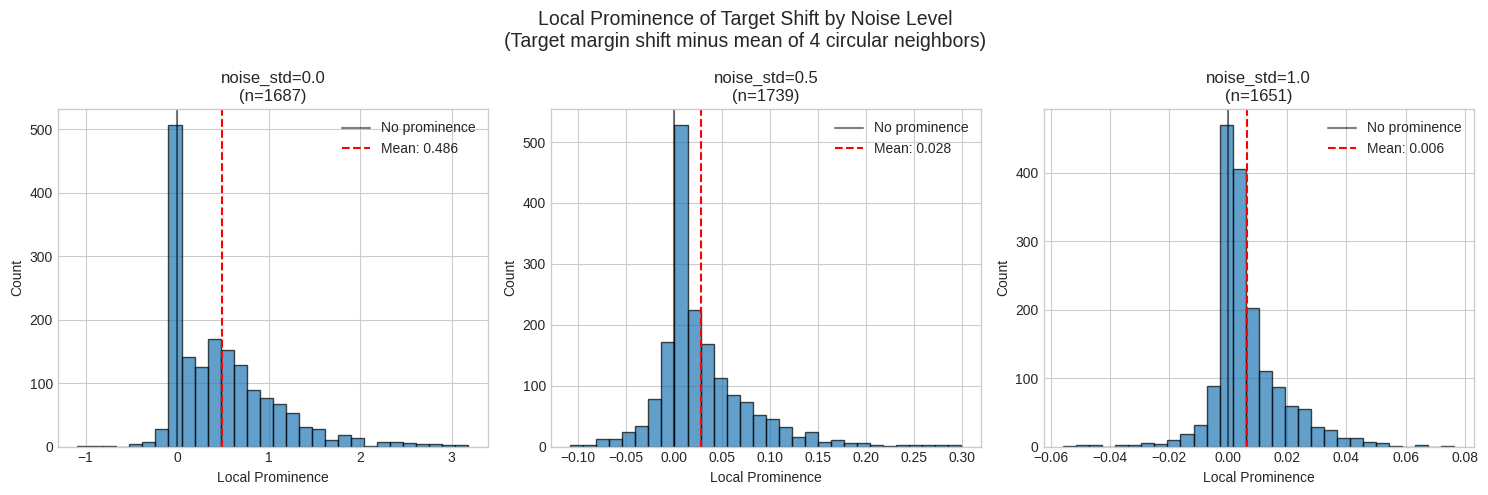


Local Prominence Statistics by Noise Level:
noise_std=0.0: mean=0.4863, median=0.3557, positive: 93.2%
noise_std=0.5: mean=0.0285, median=0.0144, positive: 83.6%
noise_std=1.0: mean=0.0063, median=0.0033, positive: 81.5%


In [20]:
# 3. LOCAL PROMINENCE: How much higher is target than its neighbors?
# Accounts for wave-like structure - positive means target is above local neighborhood

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

noise_levels = sorted(df_adv['noise_std'].unique())

for ax, noise_std in zip(axes, noise_levels):
    subset = df_adv[df_adv['noise_std'] == noise_std]
    ax.hist(subset['local_prominence'], bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='black', linestyle='-', alpha=0.5, label='No prominence')
    ax.axvline(subset['local_prominence'].mean(), color='red', linestyle='--', 
               label=f'Mean: {subset["local_prominence"].mean():.3f}')
    ax.set_xlabel('Local Prominence')
    ax.set_ylabel('Count')
    ax.set_title(f'noise_std={noise_std}\n(n={len(subset)})')
    ax.legend()

plt.suptitle('Local Prominence of Target Shift by Noise Level\n(Target margin shift minus mean of 4 circular neighbors)', fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print("\nLocal Prominence Statistics by Noise Level:")
print("="*60)
for noise_std in noise_levels:
    subset = df_adv[df_adv['noise_std'] == noise_std]
    positive_pct = (subset['local_prominence'] > 0).mean() * 100
    print(f"noise_std={noise_std}: mean={subset['local_prominence'].mean():.4f}, "
          f"median={subset['local_prominence'].median():.4f}, "
          f"positive: {positive_pct:.1f}%")

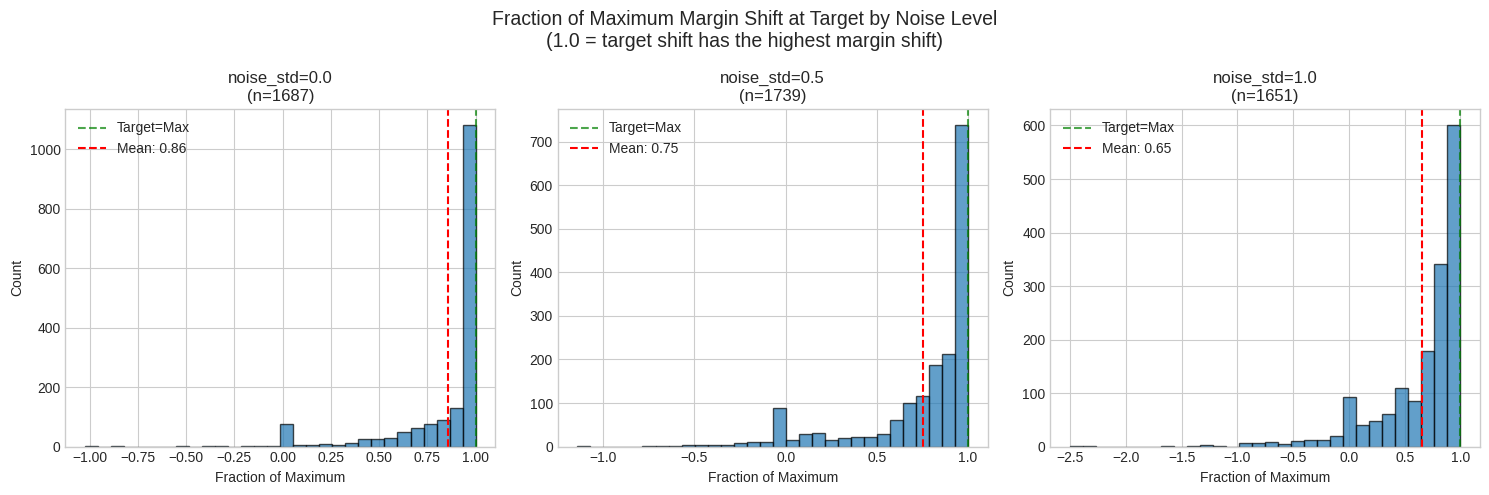


Fraction of Maximum Statistics by Noise Level:
noise_std=0.0: mean=0.856, median=1.000
  Target is max: 55.4% | Target >= 50% of max: 90.5%
noise_std=0.5: mean=0.752, median=0.888
  Target is max: 30.0% | Target >= 50% of max: 83.2%
noise_std=1.0: mean=0.655, median=0.808
  Target is max: 14.7% | Target >= 50% of max: 74.4%


In [21]:
# 4. FRACTION OF MAXIMUM: What proportion of the best effect did we achieve at target?
# 1.0 = target IS the maximum, 0.5 = target has half the effect of the best shift

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

noise_levels = sorted(df_adv['noise_std'].unique())

for ax, noise_std in zip(axes, noise_levels):
    subset = df_adv[df_adv['noise_std'] == noise_std]
    # Filter to valid values (0 to 1 range typically, but can be >1 if target is negative while max is positive)
    valid = subset['fraction_of_max']
    ax.hist(valid, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(1.0, color='green', linestyle='--', alpha=0.7, label='Target=Max')
    ax.axvline(valid.mean(), color='red', linestyle='--', 
               label=f'Mean: {valid.mean():.2f}')
    ax.set_xlabel('Fraction of Maximum')
    ax.set_ylabel('Count')
    ax.set_title(f'noise_std={noise_std}\n(n={len(subset)})')
    ax.legend()

plt.suptitle('Fraction of Maximum Margin Shift at Target by Noise Level\n(1.0 = target shift has the highest margin shift)', fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print("\nFraction of Maximum Statistics by Noise Level:")
print("="*60)
for noise_std in noise_levels:
    subset = df_adv[df_adv['noise_std'] == noise_std]
    is_max_pct = (subset['fraction_of_max'] >= 0.99).mean() * 100
    above_half_pct = (subset['fraction_of_max'] >= 0.5).mean() * 100
    print(f"noise_std={noise_std}: mean={subset['fraction_of_max'].mean():.3f}, "
          f"median={subset['fraction_of_max'].median():.3f}")
    print(f"  Target is max: {is_max_pct:.1f}% | Target >= 50% of max: {above_half_pct:.1f}%")

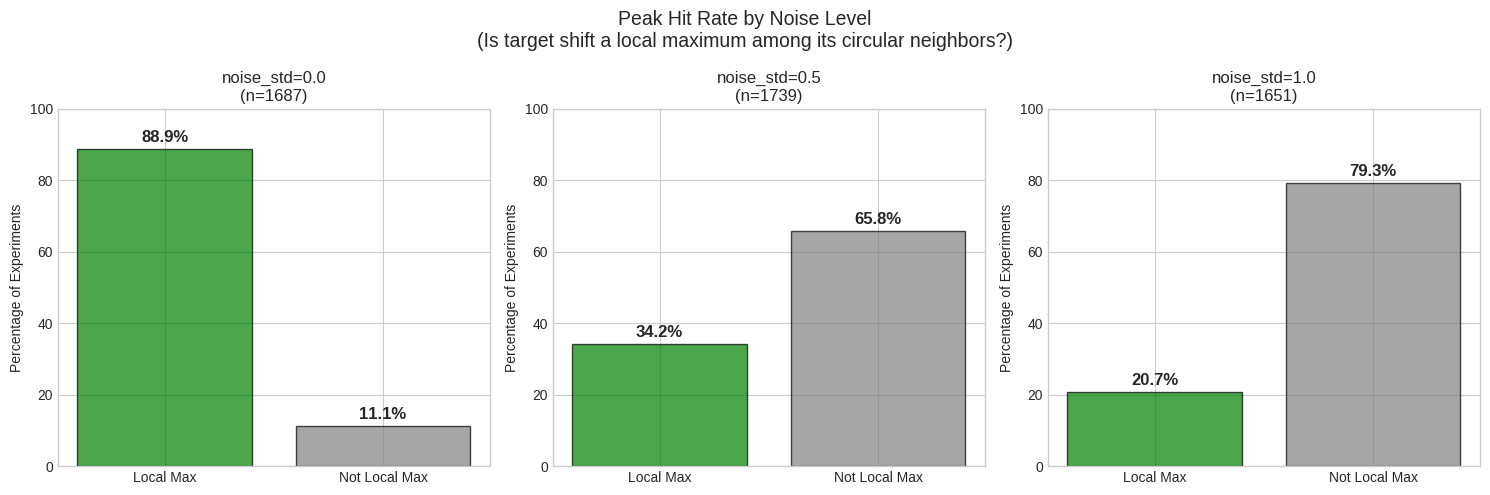


Peak Hit Rate (Local Maximum) by Noise Level:
noise_std=0.0: 88.9% of experiments have target at a local peak
noise_std=0.5: 34.2% of experiments have target at a local peak
noise_std=1.0: 20.7% of experiments have target at a local peak

(Random baseline: ~33% would be local maxima by chance)


In [22]:
# 5. PEAK HIT RATE: Is the target at a local maximum?
# True = target shift has higher margin than both immediate neighbors (circular)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

noise_levels = sorted(df_adv['noise_std'].unique())

for ax, noise_std in zip(axes, noise_levels):
    subset = df_adv[df_adv['noise_std'] == noise_std]
    local_max_rate = subset['is_local_max'].mean() * 100
    not_local_max_rate = 100 - local_max_rate
    
    bars = ax.bar(['Local Max', 'Not Local Max'], [local_max_rate, not_local_max_rate],
                  color=['green', 'gray'], edgecolor='black', alpha=0.7)
    ax.set_ylabel('Percentage of Experiments')
    ax.set_title(f'noise_std={noise_std}\n(n={len(subset)})')
    ax.set_ylim(0, 100)
    
    # Add percentage labels on bars
    for bar, pct in zip(bars, [local_max_rate, not_local_max_rate]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 2,
                f'{pct:.1f}%', ha='center', fontsize=12, fontweight='bold')

plt.suptitle('Peak Hit Rate by Noise Level\n(Is target shift a local maximum among its circular neighbors?)', fontsize=14)
plt.tight_layout()
plt.show()

# Summary
print("\nPeak Hit Rate (Local Maximum) by Noise Level:")
print("="*60)
for noise_std in noise_levels:
    subset = df_adv[df_adv['noise_std'] == noise_std]
    local_max_rate = subset['is_local_max'].mean() * 100
    print(f"noise_std={noise_std}: {local_max_rate:.1f}% of experiments have target at a local peak")

# Random baseline: if shifts were random, ~1/3 would be local maxima (middle of 3 random values)
print(f"\n(Random baseline: ~33% would be local maxima by chance)")

ADVANCED TARGETING METRICS SUMMARY BY NOISE LEVEL
 noise_std  n_experiments  mean_rank  rank_1_pct  top_3_pct  mean_z_score  z_significant_pct  mean_percentile  mean_local_prominence  prominence_positive_pct  mean_fraction_of_max  is_max_pct  local_max_pct
      0.00           1687       3.57       54.00      76.53          1.64              37.64            86.27                   0.49                    93.24                  0.86       55.36          88.86
      0.50           1739       5.91       27.20      58.65          1.16              19.95            77.29                   0.03                    83.61                  0.75       29.96          34.16
      1.00           1651       7.07       12.90      40.16          0.98               9.15            72.79                   0.01                    81.53                  0.65       14.72          20.71


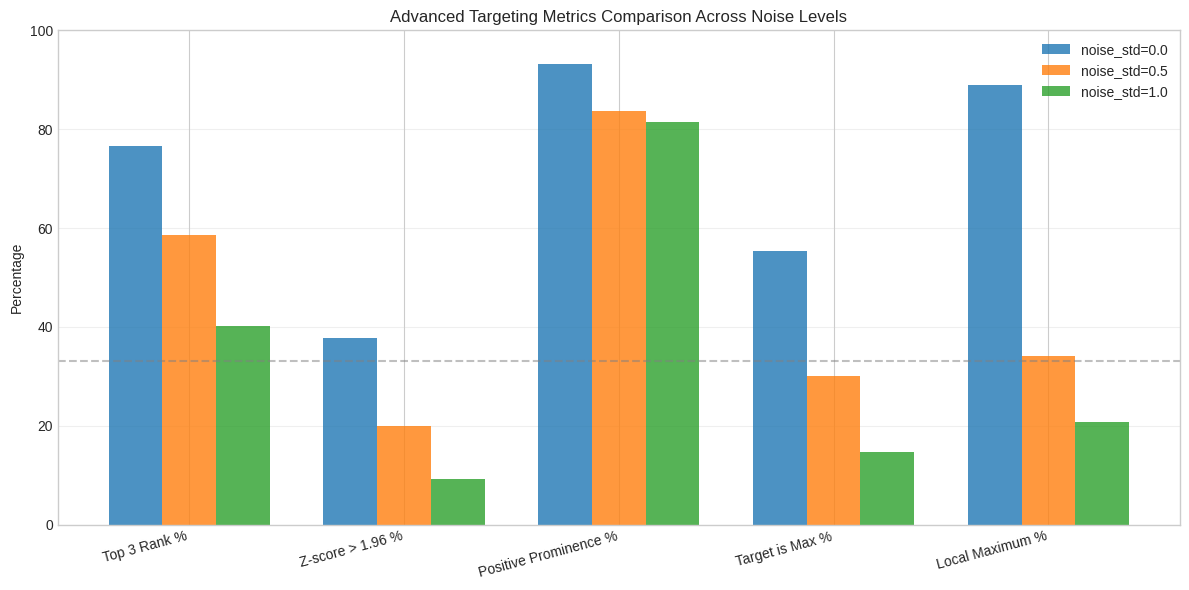


CORRELATION WITH TARGETING SCORE
  rank: r = -0.378
  z_score: r = 0.493
  percentile: r = 0.378
  local_prominence: r = 0.898
  fraction_of_max: r = 0.369


In [23]:
# 6. SUMMARY: All advanced metrics compared across noise levels

noise_levels = sorted(df_adv['noise_std'].unique())

# Create summary table
summary_data = []
for noise_std in noise_levels:
    subset = df_adv[df_adv['noise_std'] == noise_std]
    summary_data.append({
        'noise_std': noise_std,
        'n_experiments': len(subset),
        'mean_rank': subset['rank'].mean(),
        'rank_1_pct': (subset['rank'] == 1).mean() * 100,
        'top_3_pct': (subset['rank'] <= 3).mean() * 100,
        'mean_z_score': subset['z_score'].mean(),
        'z_significant_pct': (subset['z_score'] > 1.96).mean() * 100,
        'mean_percentile': subset['percentile'].mean(),
        'mean_local_prominence': subset['local_prominence'].mean(),
        'prominence_positive_pct': (subset['local_prominence'] > 0).mean() * 100,
        'mean_fraction_of_max': subset['fraction_of_max'].mean(),
        'is_max_pct': (subset['fraction_of_max'] >= 0.99).mean() * 100,
        'local_max_pct': subset['is_local_max'].mean() * 100,
    })

df_summary = pd.DataFrame(summary_data)

# Display as formatted table
print("="*80)
print("ADVANCED TARGETING METRICS SUMMARY BY NOISE LEVEL")
print("="*80)
print(df_summary.to_string(index=False, float_format='%.2f'))

# Visualization: Radar/spider chart style comparison
fig, ax = plt.subplots(figsize=(12, 6))

metrics_to_plot = ['top_3_pct', 'z_significant_pct', 'prominence_positive_pct', 'is_max_pct', 'local_max_pct']
metric_labels = ['Top 3 Rank %', 'Z-score > 1.96 %', 'Positive Prominence %', 'Target is Max %', 'Local Maximum %']

x = np.arange(len(metrics_to_plot))
width = 0.25

for i, noise_std in enumerate(noise_levels):
    row = df_summary[df_summary['noise_std'] == noise_std].iloc[0]
    values = [row[m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=f'noise_std={noise_std}', alpha=0.8)

ax.set_ylabel('Percentage')
ax.set_title('Advanced Targeting Metrics Comparison Across Noise Levels')
ax.set_xticks(x + width)
ax.set_xticklabels(metric_labels, rotation=15, ha='right')
ax.legend()
ax.axhline(33, color='gray', linestyle='--', alpha=0.5, label='Random baseline (33%)')
ax.set_ylim(0, 100)
ax.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Correlation between targeting_score and advanced metrics
print("\n" + "="*80)
print("CORRELATION WITH TARGETING SCORE")
print("="*80)
corr_metrics = ['rank', 'z_score', 'percentile', 'local_prominence', 'fraction_of_max']
for metric in corr_metrics:
    corr = df_adv['targeting_score'].corr(df_adv[metric])
    print(f"  {metric}: r = {corr:.3f}")

## 10. Load Best Experiment Visualization Data

Load the detailed visualization data from the best experiment to recreate diagnostic plots.

In [33]:
import torch
import json
import os
from pathlib import Path

# Centralized sweep results directory
SWEEP_RESULTS_DIR = Path('/lus/lfs1aip2/home/s5e/jrosser.s5e/infusion/caesar/sweep_results')
NOISE_STD_TARGET = 0.0  # Only consider experiments at this noise_std
N_PROBES_TARGET = 100   # Only consider experiments with this n_probes
best_n = 4

def load_experiment(run_id):
    """Load config, metrics, and visualization data for an experiment."""
    base = SWEEP_RESULTS_DIR / run_id
    
    config = json.load(open(base / 'config.json'))
    metrics = json.load(open(base / 'metrics.json'))
    viz_data = torch.load(base / 'visualization_data.pt', weights_only=False)
    
    return config, metrics, viz_data

def get_ranked_experiments_for_noise_and_nprobes(noise_std=0.5, n_probes=100, topn=10):
    """
    Return a list of (run_id, targeting_score) sorted by score (descending),
    only considering experiments with a given noise_std AND n_probes.
    """
    results = []
    for run_dir in SWEEP_RESULTS_DIR.iterdir():
        if not run_dir.is_dir():
            continue
        metrics_path = run_dir / 'metrics.json'
        config_path = run_dir / 'config.json'
        if not metrics_path.exists() or not config_path.exists():
            continue
        try:
            config = json.load(open(config_path))
            metrics = json.load(open(metrics_path))
            config_noise_std = float(config.get('noise_std', 'nan'))
            config_n_probes = int(config.get('n_probes', -1))
            if config_noise_std != noise_std:
                continue
            if config_n_probes != n_probes:
                continue
            score = metrics.get('targeting_score', float('-inf'))
            results.append((run_dir.name, score))
        except Exception as e:
            print(f"Error reading {run_dir}: {e}")
            continue
    # Sort by targeting_score descending
    results.sort(key=lambda x: x[1], reverse=True)
    return results[:topn]

def print_experiment_info(run_id):
    config, metrics, viz_data = load_experiment(run_id)
    
    print(f"\nConfig:")
    for k, v in sorted(config.items()):
        print(f"  {k}: {v}")
    
    print(f"\nMetrics:")
    for k, v in sorted(metrics.items()):
        if isinstance(v, float):
            print(f"  {k}: {v:.4f}")
        else:
            print(f"  {k}: {v}")
    
    print(f"\nVisualization data keys: {list(viz_data.keys())}")

# ===================
# Choose Nth best experiment (filtered by both noise_std and n_probes)
# By default, best_n=1 means highest score, best_n=2 is 2nd best, etc.

# Initialize variables that subsequent cells need
config = None
metrics = None
viz_data = None
selected_run_id = None

if SWEEP_RESULTS_DIR.exists():
    run_dirs = list(SWEEP_RESULTS_DIR.iterdir())
    print(f"Found {len(run_dirs)} experiment results in sweep_results/")
    
    ranked = get_ranked_experiments_for_noise_and_nprobes(NOISE_STD_TARGET, N_PROBES_TARGET, topn=max(10, best_n))
    if not ranked:
        print(f"No valid experiments found at noise_std={NOISE_STD_TARGET} and n_probes={N_PROBES_TARGET}!")
    else:
        print(f"\nTop targeting scores at noise_std={NOISE_STD_TARGET}, n_probes={N_PROBES_TARGET}:")
        for i, (run_id, score) in enumerate(ranked):
            print(f"  {i+1}: {run_id} (targeting_score={score:.4f})")
        
        if best_n <= len(ranked):
            selected_run_id, selected_score = ranked[best_n-1]
            print(f"\nShowing experiment ranked #{best_n}: {selected_run_id}")
            print(f"Targeting score: {selected_score:.4f}")
            
            # Load experiment data into global variables for subsequent cells
            config, metrics, viz_data = load_experiment(selected_run_id)
            print_experiment_info(selected_run_id)
        else:
            print(f"\nRequested rank {best_n}, but only {len(ranked)} experiments found with noise_std={NOISE_STD_TARGET} and n_probes={N_PROBES_TARGET}.")
else:
    print(f"Sweep results directory not found: {SWEEP_RESULTS_DIR}")
    print("Run some experiments first, or check the path.")

Found 5077 experiment results in sweep_results/

Top targeting scores at noise_std=0.0, n_probes=100:
  1: w41_s410023_k200_mn_e10_a0.1_s100_p100_ps6_ts18_n0p0 (targeting_score=2.9369)
  2: w38_s380006_k400_ma_e1_a0.1_s50_p100_ps14_ts22_n0p0 (targeting_score=2.3519)
  3: w26_s260048_k200_mn_e100_a0.1_s100_p100_ps4_ts8_n0p0 (targeting_score=2.2760)
  4: w41_s410028_k200_mn_e20.0_a0.1_s50_p100_ps6_ts24_n0p0 (targeting_score=2.2152)
  5: w28_s280017_k400_mn_e20.0_a0.1_s100_p100_ps7_ts13_n0p0 (targeting_score=2.0912)
  6: w23_s230055_k400_mn_e10_a0.1_s100_p100_ps12_ts18_n0p0 (targeting_score=2.0202)
  7: w07_s70025_k400_ma_e100_a0.1_s50_p100_ps13_ts19_n0p0 (targeting_score=2.0116)
  8: w78_s780039_k100_mn_e100_a0.1_s100_p100_ps3_ts7_n0p0 (targeting_score=1.9555)
  9: w24_s240054_k400_mn_e1_a0.1_s100_p100_ps15_ts21_n0p0 (targeting_score=1.9204)
  10: w36_s360037_k400_ma_e1_a0.1_s50_p100_ps17_ts23_n0p0 (targeting_score=1.9155)

Showing experiment ranked #4: w41_s410028_k200_mn_e20.0_a0.1_s50

## 11. Token-Level Margin Analysis

Visualize how the infusion affected token-level log probabilities for individual probes.

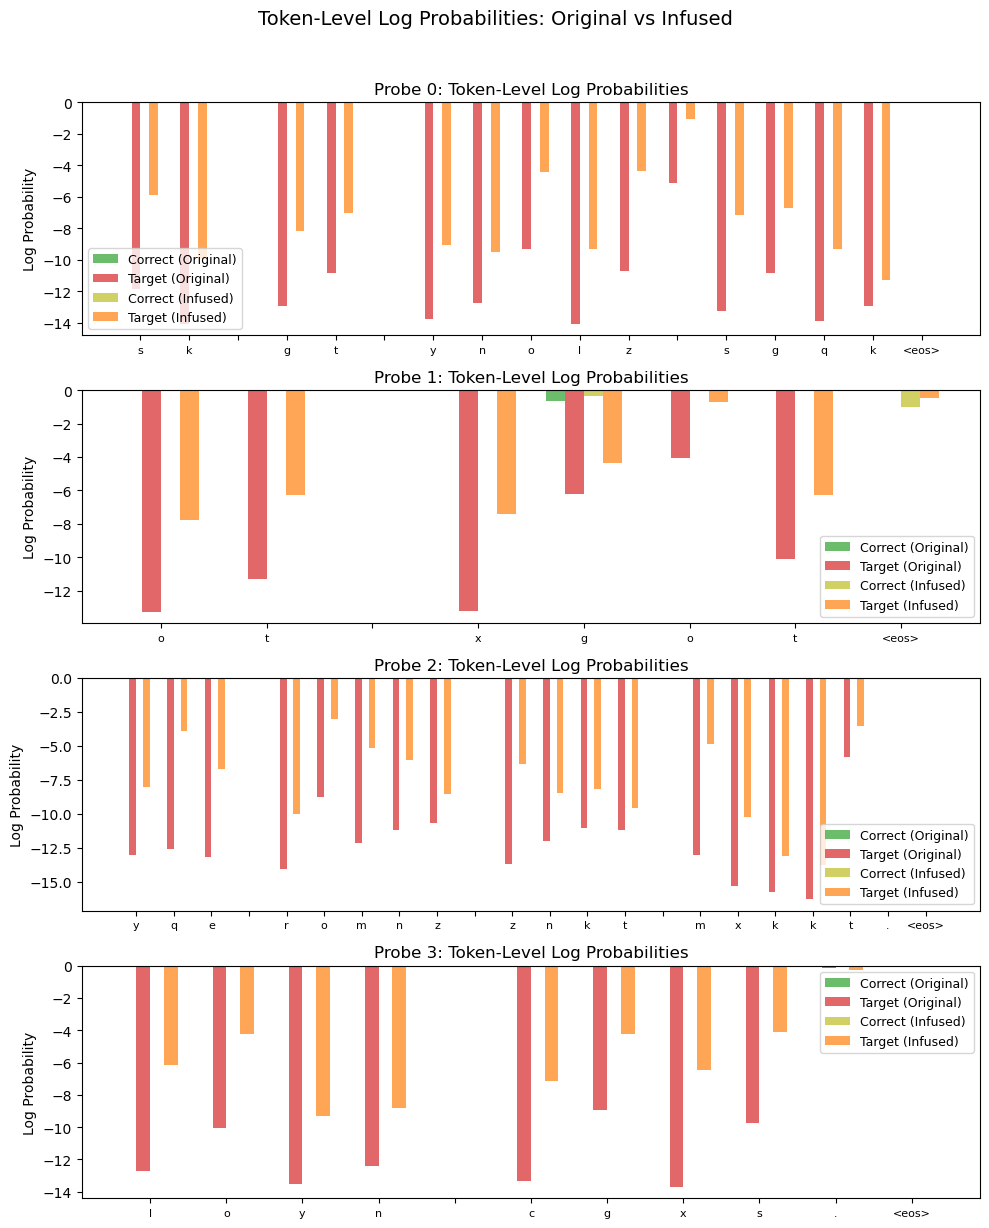

In [34]:
import matplotlib.pyplot as plt
import numpy as np

def plot_token_level_margins(token_level_data, n_probes = 4):
    """Plot token-level log probs for original vs infused model"""
    if not token_level_data:
        print("No token-level data available")
        return

    n_plots = min(n_probes, len(token_level_data))
    fig, axes = plt.subplots(n_plots, 1, figsize=(10, 3 * n_plots))
    if n_plots == 1:
        axes = [axes]  # make it iterable

    for i, probe_data in enumerate(token_level_data[:n_plots]):
        ax = axes[i]
        positions = np.arange(len(probe_data['correct_tokens']))
        width = 0.18

        # Four bars per position:
        ax.bar(positions - 1.5*width, probe_data['orig_correct_lp'], 
               width=width, label='Correct (Original)', alpha=0.7, color='tab:green')
        ax.bar(positions - 0.5*width, probe_data['orig_wrong_lp'], 
               width=width, label='Target (Original)', alpha=0.7, color='tab:red')
        ax.bar(positions + 0.5*width, probe_data['inf_correct_lp'], 
               width=width, label='Correct (Infused)', alpha=0.7, color='tab:olive')
        ax.bar(positions + 1.5*width, probe_data['inf_wrong_lp'], 
               width=width, label='Target (Infused)', alpha=0.7, color='tab:orange')

        # ax.set_yscale('log')
        ax.set_xticks(positions)
        ax.set_xticklabels(probe_data['correct_tokens'], fontsize=8)
        ax.set_ylabel('Log Probability')
        ax.set_title(f'Probe {i}: Token-Level Log Probabilities')
        ax.axhline(0, color='black', linestyle='-', alpha=0.3)

        handles, labels = ax.get_legend_handles_labels()
        # Only show unique labels
        by_label = dict(zip(labels, handles))
        ax.legend(by_label.values(), by_label.keys(), fontsize=9)

    plt.suptitle('Token-Level Log Probabilities: Original vs Infused', fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'token_level_data' in viz_data:
    plot_token_level_margins(viz_data['token_level_data'])
else:
    print("No visualization data loaded. Run the loading cell first.")

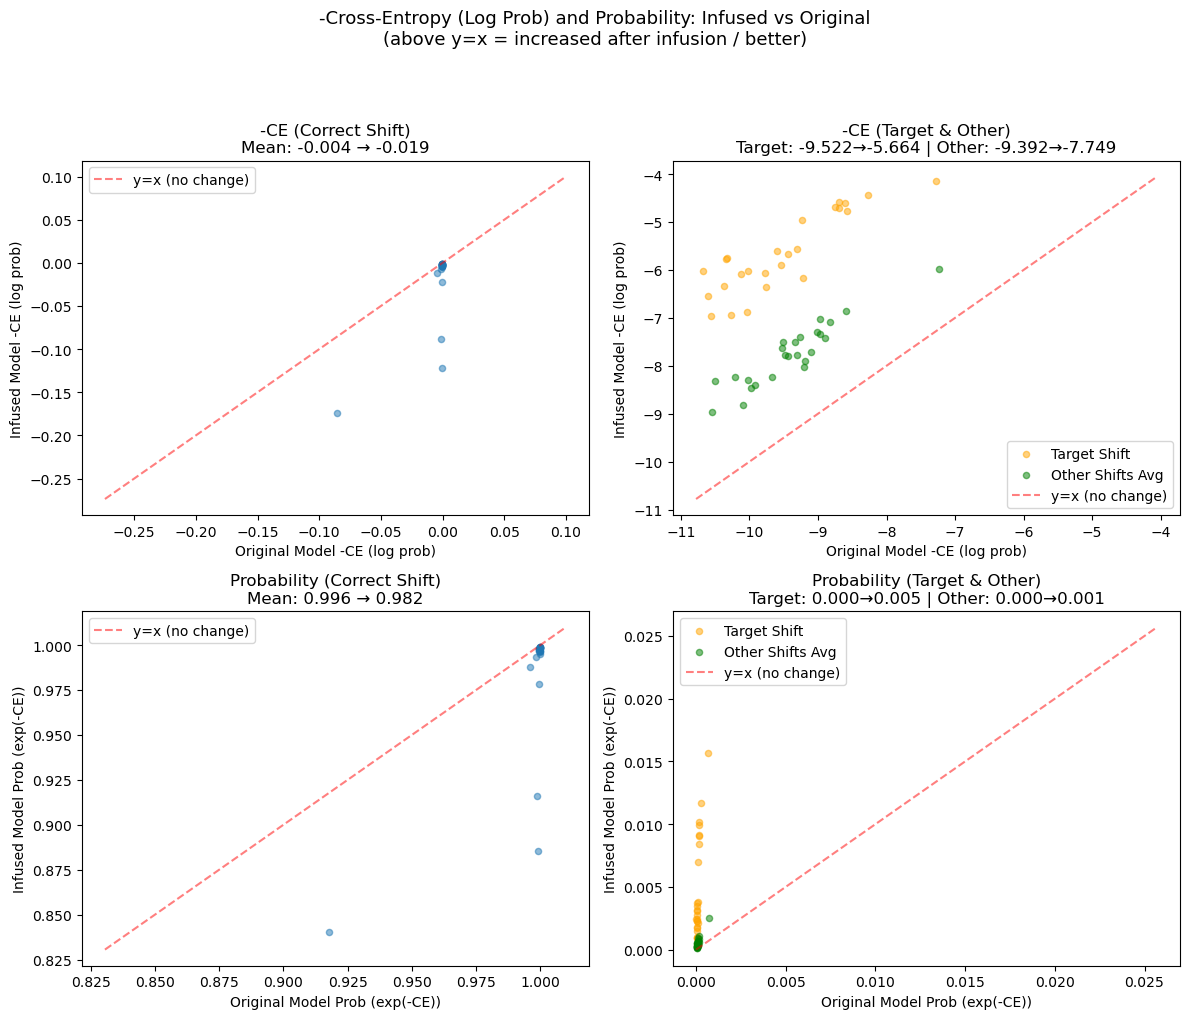


-CE Changes Summary (Infused - Original):
  Correct: -0.0148 (↓ worse)
  Target:  +3.8585 (↑ better - targeting working!)
  Other:   +1.6432

Probability Changes Summary (Infused - Original):
  Correct: -0.0139 (↓ worse)
  Target:  +0.0047 (↑ better - targeting working!)
  Other:   +0.0004


In [35]:
def plot_ce_comparison(ce_per_example):
    """Plot -CE (negative cross-entropy, log probability) and probability comparison for correct, target, and other shifts.
    
    Top: -CE scatter plots (log-probs); 
    Bottom: Probability scatter plots (exp(-CE), true probability, 0-1).
    Axes: X = Original Model, Y = Infused Model
    Points ABOVE y=x: improvement (higher after infusion, better)
    Points BELOW y=x: degradation (lower after infusion, worse)
    """
    if not ce_per_example:
        print("No CE per example data available")
        return
    
    import matplotlib.pyplot as plt
    import numpy as np

    # Prepare all data arrays
    orig = np.array(ce_per_example['ce_correct_orig'])
    inf = np.array(ce_per_example['ce_correct_inf'])
    orig_neg = -orig
    inf_neg = -inf

    orig_target = np.array(ce_per_example['ce_target_orig'])
    inf_target = np.array(ce_per_example['ce_target_inf'])
    orig_target_neg = -orig_target
    inf_target_neg = -inf_target

    orig_other = np.array(ce_per_example['ce_other_orig'])
    inf_other = np.array(ce_per_example['ce_other_inf'])
    orig_other_neg = -orig_other
    inf_other_neg = -inf_other

    # Probabilities = exp(-CE)
    prob_correct_orig = np.exp(orig_neg)
    prob_correct_inf = np.exp(inf_neg)
    prob_target_orig = np.exp(orig_target_neg)
    prob_target_inf = np.exp(inf_target_neg)
    prob_other_orig = np.exp(orig_other_neg)
    prob_other_inf = np.exp(inf_other_neg)

    # Four subplots, 2x2: logprob top, prob bottom
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))

    # --- Top row: -CE/Log Probability scatter plots ---
    # 0,0: Correct
    ax = axes[0, 0]
    ax.scatter(orig_neg, inf_neg, alpha=0.5, s=20)
    lims = [min(min(orig_neg), min(inf_neg)) - 0.1, max(max(orig_neg), max(inf_neg)) + 0.1]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='y=x (no change)')
    ax.set_xlabel('Original Model -CE (log prob)')
    ax.set_ylabel('Infused Model -CE (log prob)')
    ax.set_title(f'-CE (Correct Shift)\nMean: {np.mean(orig_neg):.3f} → {np.mean(inf_neg):.3f}')
    ax.legend()

    # 0,1: Target & other
    ax = axes[0, 1]
    ax.scatter(orig_target_neg, inf_target_neg, alpha=0.5, s=20, color='orange', label='Target Shift')
    ax.scatter(orig_other_neg, inf_other_neg, alpha=0.5, s=20, color='green', label='Other Shifts Avg')
    lims_combined = [
        min(
            min(orig_target_neg), min(inf_target_neg),
            min(orig_other_neg), min(inf_other_neg)
        ) - 0.1,
        max(
            max(orig_target_neg), max(inf_target_neg),
            max(orig_other_neg), max(inf_other_neg)
        ) + 0.1
    ]
    ax.plot(lims_combined, lims_combined, 'r--', alpha=0.5, label='y=x (no change)')
    ax.set_xlabel('Original Model -CE (log prob)')
    ax.set_ylabel('Infused Model -CE (log prob)')
    ax.set_title(
        f"-CE (Target & Other)\n"
        f"Target: {np.mean(orig_target_neg):.3f}→{np.mean(inf_target_neg):.3f} | "
        f"Other: {np.mean(orig_other_neg):.3f}→{np.mean(inf_other_neg):.3f}"
    )
    ax.legend()

    # --- Bottom row: Probability scatter plots ---
    # 1,0: Correct
    ax = axes[1, 0]
    ax.scatter(prob_correct_orig, prob_correct_inf, alpha=0.5, s=20)
    lims_prob = [min(min(prob_correct_orig), min(prob_correct_inf)) - 0.01, max(max(prob_correct_orig), max(prob_correct_inf)) + 0.01]
    lims_prob[0] = max(lims_prob[0], 0)  # Clamp at 0 minimum
    ax.plot(lims_prob, lims_prob, 'r--', alpha=0.5, label='y=x (no change)')
    ax.set_xlabel('Original Model Prob (exp(-CE))')
    ax.set_ylabel('Infused Model Prob (exp(-CE))')
    ax.set_title(f'Probability (Correct Shift)\nMean: {np.mean(prob_correct_orig):.3f} → {np.mean(prob_correct_inf):.3f}')
    ax.legend()

    # 1,1: Target & other
    ax = axes[1, 1]
    ax.scatter(prob_target_orig, prob_target_inf, alpha=0.5, s=20, color='orange', label='Target Shift')
    ax.scatter(prob_other_orig, prob_other_inf, alpha=0.5, s=20, color='green', label='Other Shifts Avg')
    lims_prob_combined = [
        min(prob_target_orig.min(), prob_target_inf.min(), prob_other_orig.min(), prob_other_inf.min()) - 0.01,
        max(prob_target_orig.max(), prob_target_inf.max(), prob_other_orig.max(), prob_other_inf.max()) + 0.01
    ]
    lims_prob_combined[0] = max(lims_prob_combined[0], 0)
    ax.plot(lims_prob_combined, lims_prob_combined, 'r--', alpha=0.5, label='y=x (no change)')
    ax.set_xlabel('Original Model Prob (exp(-CE))')
    ax.set_ylabel('Infused Model Prob (exp(-CE))')
    ax.set_title(
        f"Probability (Target & Other)\n"
        f"Target: {np.mean(prob_target_orig):.3f}→{np.mean(prob_target_inf):.3f} | "
        f"Other: {np.mean(prob_other_orig):.3f}→{np.mean(prob_other_inf):.3f}"
    )
    ax.legend()

    plt.suptitle('-Cross-Entropy (Log Prob) and Probability: Infused vs Original\n(above y=x = increased after infusion / better)', fontsize=13, y=1.015)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()
    
    # Summary (in -CE; positive delta means log-prob increased)
    print("\n-CE Changes Summary (Infused - Original):")
    delta_correct = np.mean(inf_neg) - np.mean(orig_neg)
    delta_target = np.mean(inf_target_neg) - np.mean(orig_target_neg)
    delta_other = np.mean(inf_other_neg) - np.mean(orig_other_neg)
    print(f"  Correct: {delta_correct:+.4f} {'(↑ better)' if delta_correct > 0 else '(↓ worse)'}")
    print(f"  Target:  {delta_target:+.4f} {'(↑ better - targeting working!)' if delta_target > 0 else '(↓ worse)'}")
    print(f"  Other:   {delta_other:+.4f}")

    # Probability summary
    print("\nProbability Changes Summary (Infused - Original):")
    delta_prob_correct = np.mean(prob_correct_inf) - np.mean(prob_correct_orig)
    delta_prob_target = np.mean(prob_target_inf) - np.mean(prob_target_orig)
    delta_prob_other = np.mean(prob_other_inf) - np.mean(prob_other_orig)
    print(f"  Correct: {delta_prob_correct:+.4f} {'(↑ better)' if delta_prob_correct > 0 else '(↓ worse)'}")
    print(f"  Target:  {delta_prob_target:+.4f} {'(↑ better - targeting working!)' if delta_prob_target > 0 else '(↓ worse)'}")
    print(f"  Other:   {delta_prob_other:+.4f}")

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'ce_per_example' in viz_data:
    plot_ce_comparison(viz_data['ce_per_example'])
else:
    print("No CE per example data available.")

## 13. Measurement Values Comparison

Compare the task measurement (margin) values for all probes before/after infusion.

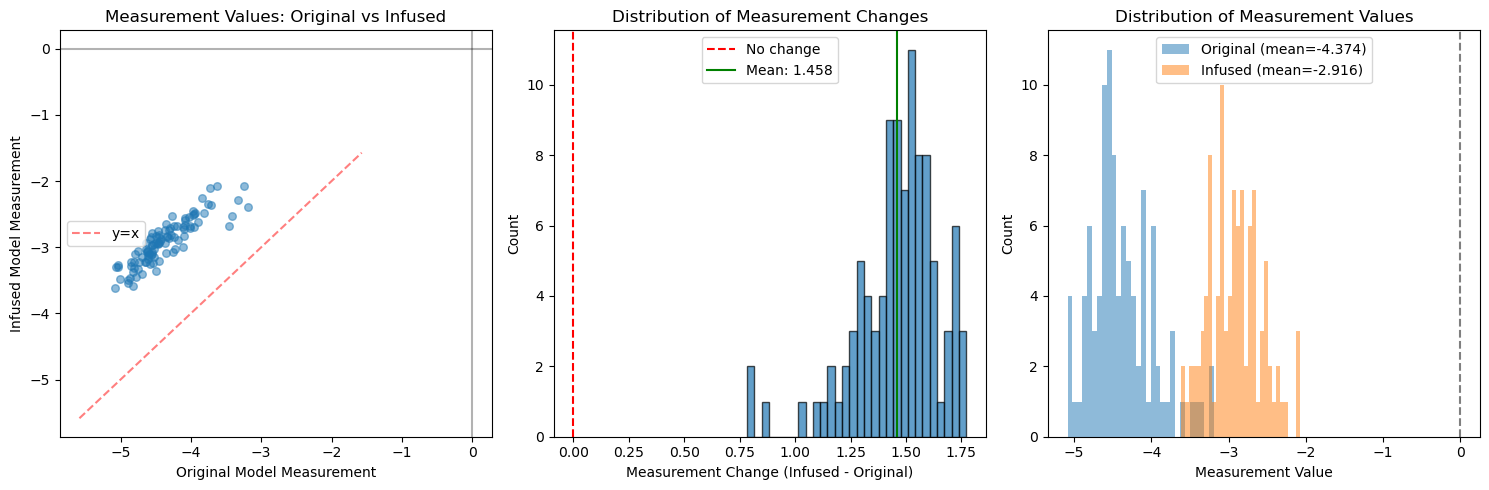


Measurement Statistics:
  Original: mean=-4.3740, std=0.4069
  Infused:  mean=-2.9158, std=0.3425
  Change:   mean=+1.4582
  Probes improved (change > 0): 100 / 100


In [36]:
def plot_measurement_comparison(measurement_values):
    """Plot measurement values comparison original vs infused."""
    if not measurement_values:
        print("No measurement values data available")
        return
    
    orig = measurement_values['measurements_orig']
    inf = measurement_values['measurements_inf']
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Scatter plot
    ax = axes[0]
    ax.scatter(orig, inf, alpha=0.5, s=30)
    lims = [min(min(orig), min(inf)) - 0.5, max(max(orig), max(inf)) + 0.5]
    ax.plot(lims, lims, 'r--', alpha=0.5, label='y=x')
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.axvline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel('Original Model Measurement')
    ax.set_ylabel('Infused Model Measurement')
    ax.set_title('Measurement Values: Original vs Infused')
    ax.legend()
    
    # Histogram of changes
    ax = axes[1]
    changes = np.array(inf) - np.array(orig)
    ax.hist(changes, bins=30, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', label='No change')
    ax.axvline(np.mean(changes), color='green', linestyle='-', 
               label=f'Mean: {np.mean(changes):.3f}')
    ax.set_xlabel('Measurement Change (Infused - Original)')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Measurement Changes')
    ax.legend()
    
    # Histogram of values
    ax = axes[2]
    ax.hist(orig, bins=30, alpha=0.5, label=f'Original (mean={np.mean(orig):.3f})')
    ax.hist(inf, bins=30, alpha=0.5, label=f'Infused (mean={np.mean(inf):.3f})')
    ax.axvline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Measurement Value')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Measurement Values')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary stats
    print(f"\nMeasurement Statistics:")
    print(f"  Original: mean={np.mean(orig):.4f}, std={np.std(orig):.4f}")
    print(f"  Infused:  mean={np.mean(inf):.4f}, std={np.std(inf):.4f}")
    print(f"  Change:   mean={np.mean(changes):+.4f}")
    print(f"  Probes improved (change > 0): {np.sum(np.array(changes) > 0)} / {len(changes)}")

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'measurement_values' in viz_data:
    plot_measurement_comparison(viz_data['measurement_values'])
else:
    print("No measurement values data available.")

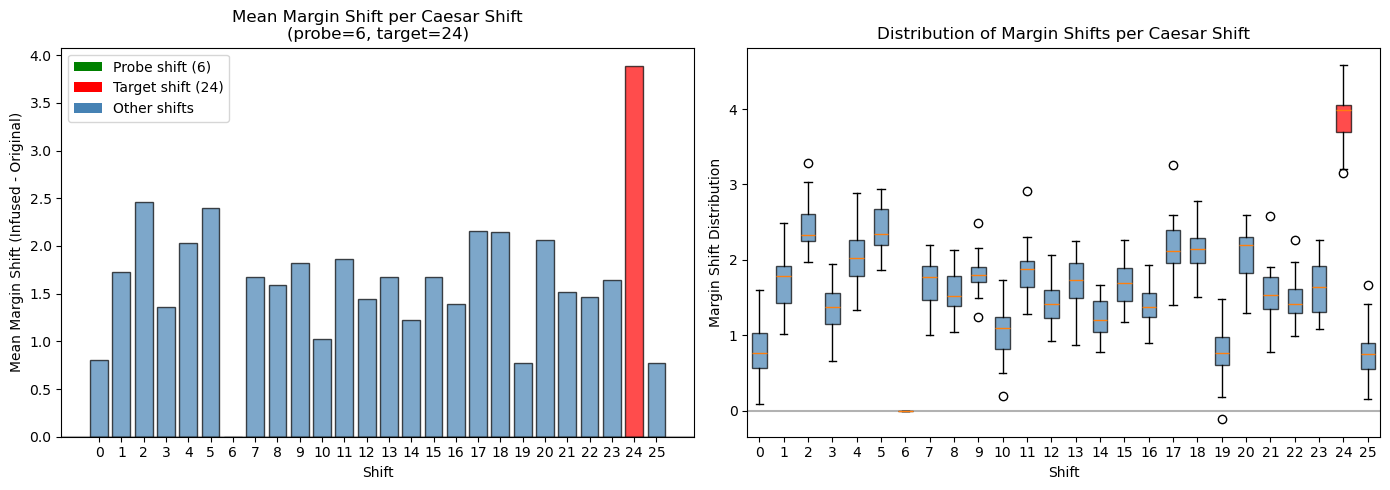


Margin Shift Summary:
  Probe shift (6): +0.0000
  Target shift (24): +3.8841
  Other shifts (avg): +1.6113


In [37]:
def plot_margin_shifts_all(margin_shifts_per_example, config):
    """Plot mean margin shifts for all 26 shifts."""
    if not margin_shifts_per_example:
        print("No margin shifts data available")
        return
    
    probe_shift = config.get('probe_shift', 0)
    target_shift = config.get('target_shift', 0)
    
    # Handle both int and string keys
    shifts = sorted([int(s) for s in margin_shifts_per_example.keys()])
    
    def get_shift_data(s):
        """Get data for shift s, handling both int and string keys."""
        if s in margin_shifts_per_example:
            return margin_shifts_per_example[s]
        elif str(s) in margin_shifts_per_example:
            return margin_shifts_per_example[str(s)]
        return []
    
    mean_margins = [np.mean(get_shift_data(s)) for s in shifts]
    std_margins = [np.std(get_shift_data(s)) for s in shifts]
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Bar plot of mean margins
    ax = axes[0]
    colors = ['green' if s == probe_shift else 'red' if s == target_shift else 'steelblue' 
              for s in shifts]
    bars = ax.bar(shifts, mean_margins, color=colors, alpha=0.7, edgecolor='black')
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel('Shift')
    ax.set_ylabel('Mean Margin Shift (Infused - Original)')
    ax.set_title(f'Mean Margin Shift per Caesar Shift\n(probe={probe_shift}, target={target_shift})')
    ax.set_xticks(shifts)
    
    # Add legend
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor='green', label=f'Probe shift ({probe_shift})'),
                       Patch(facecolor='red', label=f'Target shift ({target_shift})'),
                       Patch(facecolor='steelblue', label='Other shifts')]
    ax.legend(handles=legend_elements)
    
    # Box plot per shift
    ax = axes[1]
    data_for_box = [get_shift_data(s) for s in shifts]
    bp = ax.boxplot(data_for_box, positions=shifts, widths=0.6, patch_artist=True)
    for i, (patch, shift) in enumerate(zip(bp['boxes'], shifts)):
        if shift == probe_shift:
            patch.set_facecolor('green')
        elif shift == target_shift:
            patch.set_facecolor('red')
        else:
            patch.set_facecolor('steelblue')
        patch.set_alpha(0.7)
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel('Shift')
    ax.set_ylabel('Margin Shift Distribution')
    ax.set_title('Distribution of Margin Shifts per Caesar Shift')
    ax.set_xticks(shifts)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"\nMargin Shift Summary:")
    print(f"  Probe shift ({probe_shift}): {mean_margins[probe_shift]:+.4f}")
    print(f"  Target shift ({target_shift}): {mean_margins[target_shift]:+.4f}")
    other_means = [m for i, m in enumerate(mean_margins) if i != probe_shift and i != target_shift]
    print(f"  Other shifts (avg): {np.mean(other_means):+.4f}")

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'margin_shifts_per_example' in viz_data:
    plot_margin_shifts_all(viz_data['margin_shifts_per_example'], config)
else:
    print("No margin shifts data available.")

## 15. Influence Score Distribution

Analyze the distribution of influence scores and which training examples were selected.

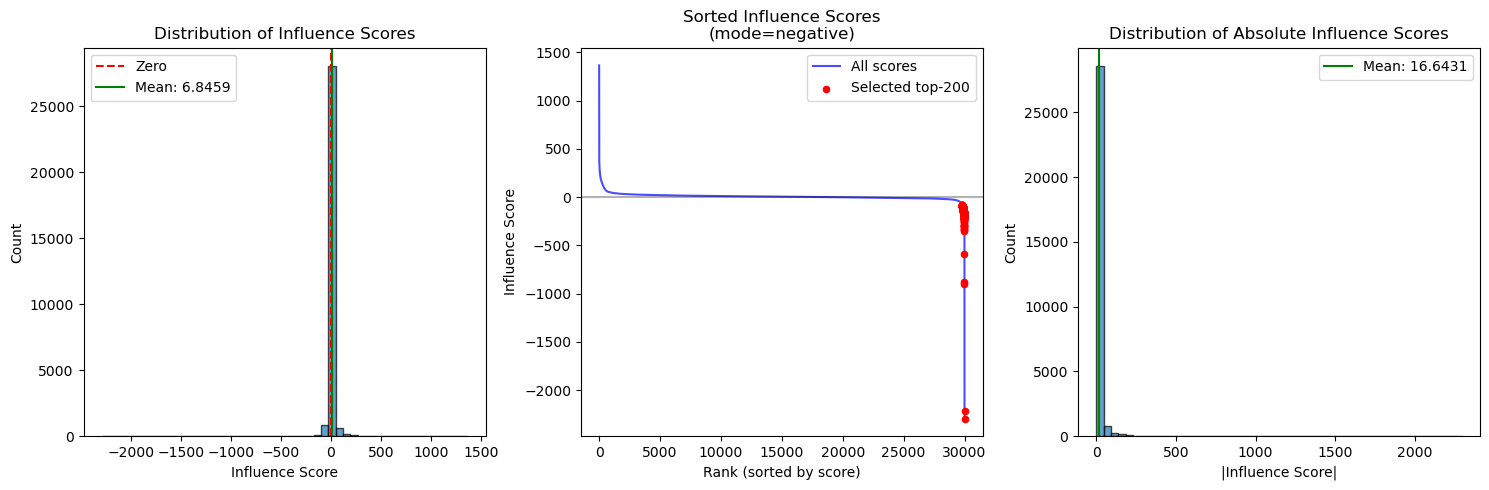


Influence Score Summary:
  Total examples: 30000
  Mean: 6.8459, Std: 37.9949
  Min: -2294.9619, Max: 1365.6497
  Positive: 19212 (64.0%)

Selected top-200 (mode=negative):
  Mean: -180.0735
  Min: -2294.9619, Max: -84.0076


In [38]:
def plot_influence_scores(viz_data, config):
    """Plot influence score distribution and top-k selection."""
    probe_scores = viz_data.get('probe_scores_full', [])
    top_k_indices = viz_data.get('top_k_indices', [])
    
    if not probe_scores:
        print("No influence scores data available")
        return
    
    scores = np.array(probe_scores)
    top_k = config.get('top_k', len(top_k_indices))
    top_k_mode = config.get('top_k_mode', 'absolute')
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    # Histogram of all scores
    ax = axes[0]
    ax.hist(scores, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(0, color='red', linestyle='--', label='Zero')
    ax.axvline(np.mean(scores), color='green', linestyle='-', 
               label=f'Mean: {np.mean(scores):.4f}')
    ax.set_xlabel('Influence Score')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Influence Scores')
    ax.legend()
    
    # Sorted scores with top-k highlighted
    ax = axes[1]
    sorted_indices = np.argsort(scores)[::-1]  # Descending
    sorted_scores = scores[sorted_indices]
    
    ax.plot(range(len(sorted_scores)), sorted_scores, 'b-', alpha=0.7, label='All scores')
    
    # Highlight top-k
    top_k_set = set(top_k_indices)
    top_k_positions = [i for i, idx in enumerate(sorted_indices) if idx in top_k_set]
    top_k_vals = [sorted_scores[i] for i in top_k_positions]
    ax.scatter(top_k_positions, top_k_vals, c='red', s=20, label=f'Selected top-{top_k}', zorder=5)
    
    ax.axhline(0, color='black', linestyle='-', alpha=0.3)
    ax.set_xlabel('Rank (sorted by score)')
    ax.set_ylabel('Influence Score')
    ax.set_title(f'Sorted Influence Scores\n(mode={top_k_mode})')
    ax.legend()
    
    # Absolute score distribution
    ax = axes[2]
    abs_scores = np.abs(scores)
    ax.hist(abs_scores, bins=50, edgecolor='black', alpha=0.7)
    ax.axvline(np.mean(abs_scores), color='green', linestyle='-',
               label=f'Mean: {np.mean(abs_scores):.4f}')
    ax.set_xlabel('|Influence Score|')
    ax.set_ylabel('Count')
    ax.set_title('Distribution of Absolute Influence Scores')
    ax.legend()
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    print(f"\nInfluence Score Summary:")
    print(f"  Total examples: {len(scores)}")
    print(f"  Mean: {np.mean(scores):.4f}, Std: {np.std(scores):.4f}")
    print(f"  Min: {np.min(scores):.4f}, Max: {np.max(scores):.4f}")
    print(f"  Positive: {np.sum(scores > 0)} ({100*np.mean(scores > 0):.1f}%)")
    if top_k_indices:
        selected_scores = scores[top_k_indices]
        print(f"\nSelected top-{len(top_k_indices)} (mode={top_k_mode}):")
        print(f"  Mean: {np.mean(selected_scores):.4f}")
        print(f"  Min: {np.min(selected_scores):.4f}, Max: {np.max(selected_scores):.4f}")

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'probe_scores_full' in viz_data:
    plot_influence_scores(viz_data, config)
else:
    print("No influence scores data available.")

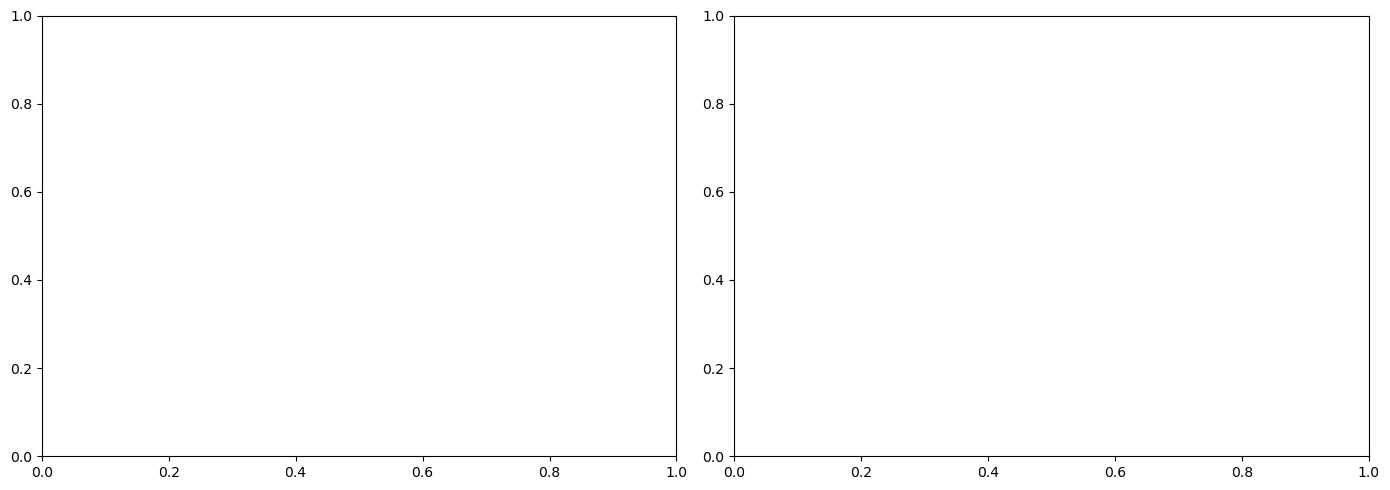

In [39]:
def plot_influential_shift_distribution(influential_shift_distribution, config):
    """Plot the shift distribution in influential training examples."""
    if not influential_shift_distribution:
        print("No influential shift distribution data available")
        return
    
    probe_shift = config.get('probe_shift', 0)
    target_shift = config.get('target_shift', 0)
    
    def get_count(d, s):
        """Get count for shift s, handling both int and string keys."""
        if s in d:
            return d[s]
        elif str(s) in d:
            return d[str(s)]
        return 0
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Aggregate shifts (all shifts in top-k examples)
    ax = axes[0]
    agg_shifts = influential_shift_distribution.get('aggregate_shifts', {})
    if agg_shifts:
        shifts = list(range(26))
        counts = [get_count(agg_shifts, s) for s in shifts]
        colors = ['green' if s == probe_shift else 'red' if s == target_shift else 'steelblue' 
                  for s in shifts]
        ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Caesar Shift')
        ax.set_ylabel('Count in Top-K')
        ax.set_title(f'Shift Distribution in Influential Examples\n(probe={probe_shift}, target={target_shift})')
        ax.set_xticks(shifts)
    
    # Claimed shifts (shift of each example based on index)
    ax = axes[1]
    claimed_shifts = influential_shift_distribution.get('claimed_shifts', {})
    if claimed_shifts:
        shifts = list(range(26))
        counts = [get_count(claimed_shifts, s) for s in shifts]
        colors = ['green' if s == probe_shift else 'red' if s == target_shift else 'steelblue' 
                  for s in shifts]
        ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
        ax.set_xlabel('Caesar Shift')
        ax.set_ylabel('Count')
        ax.set_title('Claimed Shift of Influential Examples')
        ax.set_xticks(shifts)
    
    plt.tight_layout()
    plt.show()
    
    # Summary
    if agg_shifts:
        print("\nAggregate Shift Distribution:")
        probe_count = get_count(agg_shifts, probe_shift)
        target_count = get_count(agg_shifts, target_shift)
        total = sum(agg_shifts.values())
        if total > 0:
            print(f"  Probe shift ({probe_shift}): {probe_count} ({100*probe_count/total:.1f}%)")
            print(f"  Target shift ({target_shift}): {target_count} ({100*target_count/total:.1f}%)")

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'influential_shift_distribution' in viz_data:
    plot_influential_shift_distribution(viz_data['influential_shift_distribution'], config)
else:
    print("No influential shift distribution data available.")

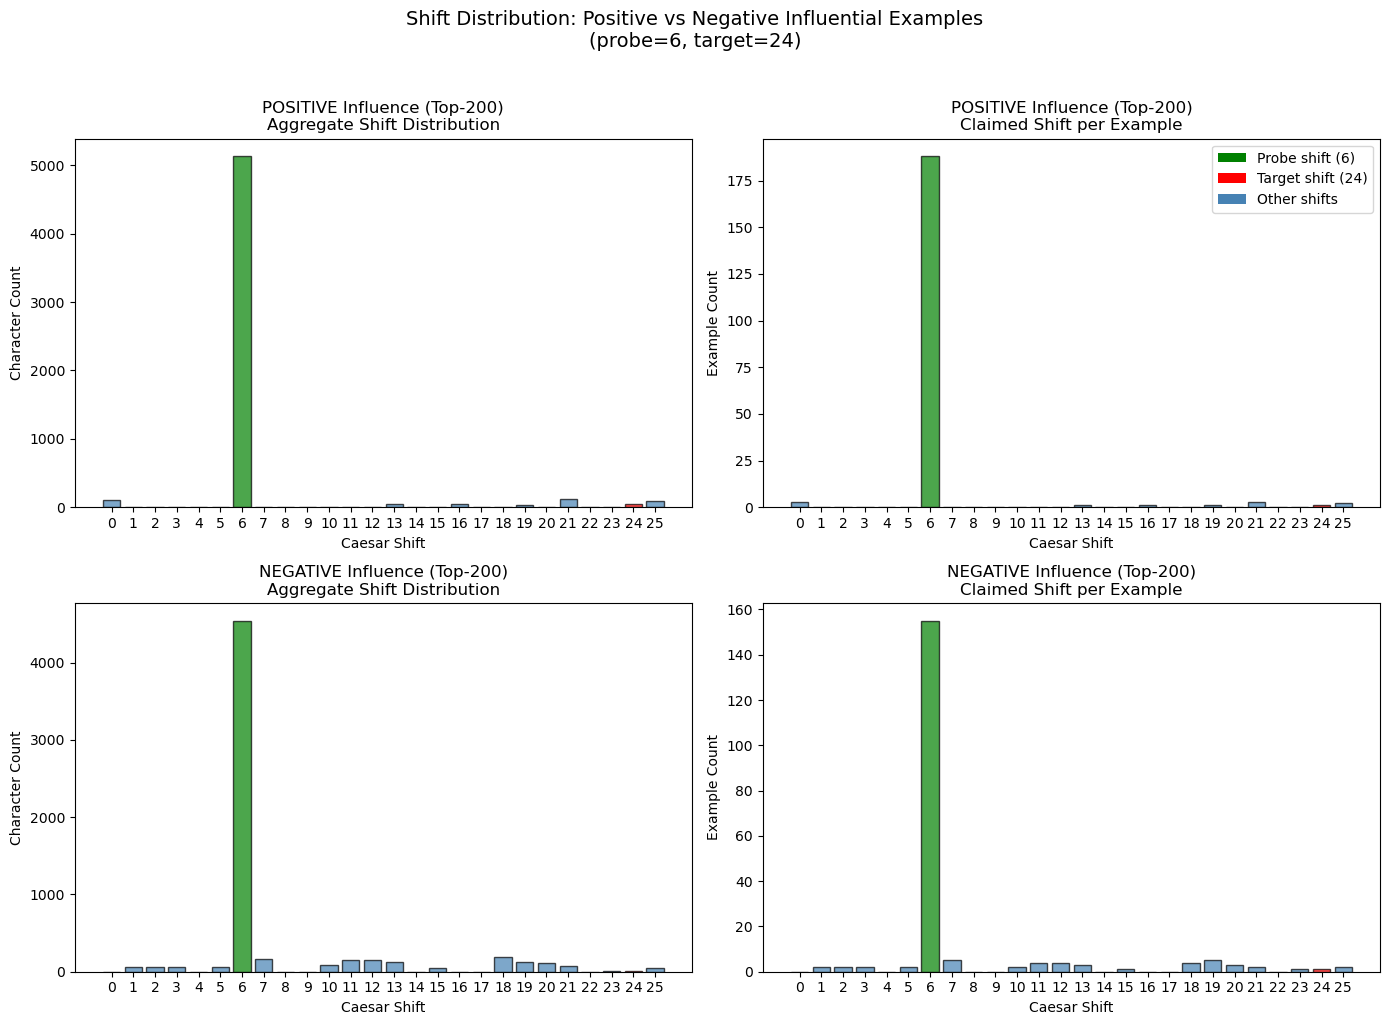


Influential Examples Analysis (Top-200 each):

  POSITIVE influence:
    Probe shift (6): 5133 chars (91.0%)
    Target shift (24): 47 chars (0.8%)
    Examples with probe shift: 188/200
    Examples with target shift: 1/200

  NEGATIVE influence:
    Probe shift (6): 4542 chars (74.8%)
    Target shift (24): 9 chars (0.1%)
    Examples with probe shift: 155/200
    Examples with target shift: 1/200


In [40]:
def plot_influential_shift_distribution(influential_shift_distribution, config):
    """Plot the shift distribution in influential training examples (positive vs negative)."""
    if not influential_shift_distribution:
        print("No influential shift distribution data available")
        return
    
    probe_shift = config.get('probe_shift', 0)
    target_shift = config.get('target_shift', 0)
    top_k = config.get('top_k', '?')
    
    def get_count(d, s):
        """Get count for shift s, handling both int and string keys."""
        if s in d:
            return d[s]
        elif str(s) in d:
            return d[str(s)]
        return 0
    
    # Check if using new format (positive/negative) or old format
    if 'positive' in influential_shift_distribution and 'negative' in influential_shift_distribution:
        # New format: separate positive and negative distributions
        pos_dist = influential_shift_distribution['positive']
        neg_dist = influential_shift_distribution['negative']
        
        fig, axes = plt.subplots(2, 2, figsize=(14, 10))
        
        shifts = list(range(26))
        colors = ['green' if s == probe_shift else 'red' if s == target_shift else 'steelblue' 
                  for s in shifts]
        
        # Top row: Positive influence examples
        # Aggregate shifts
        ax = axes[0, 0]
        agg_shifts = pos_dist.get('aggregate_shifts', {})
        if agg_shifts:
            counts = [get_count(agg_shifts, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Character Count')
            ax.set_title(f'POSITIVE Influence (Top-{top_k})\nAggregate Shift Distribution')
            ax.set_xticks(shifts)
        
        # Claimed shifts
        ax = axes[0, 1]
        claimed = pos_dist.get('claimed_shifts', {})
        if claimed:
            counts = [get_count(claimed, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Example Count')
            ax.set_title(f'POSITIVE Influence (Top-{top_k})\nClaimed Shift per Example')
            ax.set_xticks(shifts)
        
        # Bottom row: Negative influence examples
        # Aggregate shifts
        ax = axes[1, 0]
        agg_shifts = neg_dist.get('aggregate_shifts', {})
        if agg_shifts:
            counts = [get_count(agg_shifts, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Character Count')
            ax.set_title(f'NEGATIVE Influence (Top-{top_k})\nAggregate Shift Distribution')
            ax.set_xticks(shifts)
        
        # Claimed shifts
        ax = axes[1, 1]
        claimed = neg_dist.get('claimed_shifts', {})
        if claimed:
            counts = [get_count(claimed, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Example Count')
            ax.set_title(f'NEGATIVE Influence (Top-{top_k})\nClaimed Shift per Example')
            ax.set_xticks(shifts)
        
        # Add legend
        from matplotlib.patches import Patch
        legend_elements = [
            Patch(facecolor='green', label=f'Probe shift ({probe_shift})'),
            Patch(facecolor='red', label=f'Target shift ({target_shift})'),
            Patch(facecolor='steelblue', label='Other shifts')
        ]
        axes[0, 1].legend(handles=legend_elements, loc='upper right')
        
        plt.suptitle(f'Shift Distribution: Positive vs Negative Influential Examples\n(probe={probe_shift}, target={target_shift})', 
                     fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()
        
        # Summary
        print(f"\nInfluential Examples Analysis (Top-{top_k} each):")
        for label, dist in [('POSITIVE', pos_dist), ('NEGATIVE', neg_dist)]:
            agg = dist.get('aggregate_shifts', {})
            claimed = dist.get('claimed_shifts', {})
            if agg:
                total_chars = sum(agg.values())
                probe_chars = get_count(agg, probe_shift)
                target_chars = get_count(agg, target_shift)
                print(f"\n  {label} influence:")
                if total_chars > 0:
                    print(f"    Probe shift ({probe_shift}): {probe_chars} chars ({100*probe_chars/total_chars:.1f}%)")
                    print(f"    Target shift ({target_shift}): {target_chars} chars ({100*target_chars/total_chars:.1f}%)")
                if claimed:
                    total_ex = sum(claimed.values())
                    probe_ex = get_count(claimed, probe_shift)
                    target_ex = get_count(claimed, target_shift)
                    print(f"    Examples with probe shift: {probe_ex}/{total_ex}")
                    print(f"    Examples with target shift: {target_ex}/{total_ex}")
    
    else:
        # Old format: single distribution (backwards compatibility)
        top_k_mode = config.get('top_k_mode', 'absolute')
        mode_desc = {
            'absolute': f'Top-{top_k} by |Influence|',
            'positive': f'Top-{top_k} Most Positive Influence',
            'negative': f'Top-{top_k} Most Negative Influence',
        }.get(top_k_mode, f'Top-{top_k} ({top_k_mode})')
        
        fig, axes = plt.subplots(1, 2, figsize=(14, 5))
        shifts = list(range(26))
        colors = ['green' if s == probe_shift else 'red' if s == target_shift else 'steelblue' 
                  for s in shifts]
        
        ax = axes[0]
        agg_shifts = influential_shift_distribution.get('aggregate_shifts', {})
        if agg_shifts:
            counts = [get_count(agg_shifts, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Character Count')
            ax.set_title(f'Aggregate Shift Distribution\n{mode_desc}')
            ax.set_xticks(shifts)
        
        ax = axes[1]
        claimed = influential_shift_distribution.get('claimed_shifts', {})
        if claimed:
            counts = [get_count(claimed, s) for s in shifts]
            ax.bar(shifts, counts, color=colors, alpha=0.7, edgecolor='black')
            ax.set_xlabel('Caesar Shift')
            ax.set_ylabel('Example Count')
            ax.set_title(f'Claimed Shift per Example\n{mode_desc}')
            ax.set_xticks(shifts)
        
        plt.tight_layout()
        plt.show()

# Plot if data is loaded
if 'viz_data' in dir() and viz_data and 'influential_shift_distribution' in viz_data:
    plot_influential_shift_distribution(viz_data['influential_shift_distribution'], config)
else:
    print("No influential shift distribution data available.")